# Universal QAE Evaluation Framework

**Note:** This notebook may cause kernel crashes due to high thread usage. The first cell limits thread count to prevent this. If crashes persist, adjust Jupyter config:

    c.MappingKernelManager.cull_idle_timeout = 300
    c.KernelManager.transport_wait_time = 60.0

In [1]:
# Thread Limiting (prevent kernel crashes)
import os

# Limit threads to P-cores only (i9-13900K: 8 Performance cores)
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["TORCH_NUM_THREADS"] = "8"

# Intel-specific thread pinning
os.environ["KMP_AFFINITY"] = "granularity=fine,compact,1,0"

In [2]:
# Configuration
import numpy as np

QAE_RUNS_ROOTS = {
    "monolith": "../Monolith_QAE/qae_runs",
    "sidekick": "../Sidekick_QAE/qae_runs",
    "stacked": "../Stacked_QAE/qae_runs"
}

DATA_ROOT = "../data"
FRAMEWORK_OUT = "./eval_results_L4"

DATASETS = [
    "mackey_glass_tau17_n200",
    "mackey_glass_tau30_n200"
]

TEST_NOISE_LEVELS = [0.2]
TEST_SEED_BASE = 99123

MAKE_PLOTS = True
SAVE_INDIVIDUAL_BUNDLES = True

# Set to e.g. "4q_2l_2t" to filter, or None for all architectures
ARCH_FILTER = None

In [3]:
# Imports & Utilities
import os, json, re, sys, time
from pathlib import Path
from typing import Dict, Any, Tuple, List, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import pennylane as qml
from pennylane import numpy as pnp

try:
    from scipy import stats as sp_stats
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False
    print("Warning: SciPy not found. p-values will be approximated.")

sys.path.append('..')
sys.path.append('../..')
sys.path.append('../../..')

from qae_utils.Files import read_json_file, read_ts_file
from qae_utils.Window import ts_wind_make, ts_wind_split, ts_wind_flatten_avg, ts_add_noise

Path(FRAMEWORK_OUT).mkdir(parents=True, exist_ok=True)

np.set_printoptions(suppress=True, precision=6)
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Framework initialized. Output: {FRAMEWORK_OUT}")
print(f"Datasets: {DATASETS}")


def x2y(x, xlim=(0, 1), ylim=(0, np.pi)):
    """Scale values from xlim range to ylim range (vectorized)."""
    low_x, high_x = xlim
    low_y, high_y = ylim
    input_range_length = high_x - low_x
    if np.isclose(input_range_length, 0.0):
        return (low_y + high_y) / 2
    scaling_factor = (high_y - low_y) / input_range_length
    return low_y + (x - low_x) * scaling_factor

Framework initialized. Output: ./eval_results_L4
Datasets: ['mackey_glass_tau17_n200', 'mackey_glass_tau30_n200']


In [4]:
# Data Loading

def load_dataset(data_id: str) -> Tuple[np.ndarray, Dict[str, float]]:
    """Load dataset with robust path searching."""
    candidates = [
        Path(DATA_ROOT) / data_id,
        Path("../data") / data_id,
        Path("../../data") / data_id,
        Path("../dev/data") / data_id,
    ]
    
    for folder in candidates:
        info_path = folder / "info.json"
        y_path = folder / "y_org.arr"
        
        if info_path.exists() and y_path.exists():
            info = read_json_file(str(info_path))
            y = read_ts_file(str(y_path))
            
            return np.asarray(y), {
                "scale_low": float(info["scale_low"]),
                "scale_high": float(info["scale_high"]),
                "folder": str(folder.resolve())
            }
    
    raise FileNotFoundError(f"Dataset '{data_id}' not found in: {[str(c) for c in candidates]}")


def generate_test_windows(
    y: np.ndarray,
    sigma: float,
    seed: int,
    wind_size: int,
    wind_step: int,
    split: float,
    scale_low: float,
    scale_high: float,
    noise_clip: bool = True
) -> Tuple[np.ndarray, ...]:
    """Generate clean and noisy windows with deterministic seed."""
    y_noisy = ts_add_noise(
        y, noise=sigma, noise_type='normal', clip=noise_clip,
        range_low=scale_low, range_high=scale_high, seed=int(seed)
    )
    
    win_clean = ts_wind_make(y, wind_size, wind_step)
    win_noisy = ts_wind_make(y_noisy, wind_size, wind_step)
    X_ts = np.array([i * wind_step for i in range(len(win_clean))])
    
    _, tr_clean, _, te_clean = ts_wind_split(X_ts, win_clean, split)
    _, tr_noisy, _, te_noisy = ts_wind_split(X_ts, win_noisy, split)
    
    return (np.asarray(tr_clean), np.asarray(tr_noisy),
            np.asarray(te_clean), np.asarray(te_noisy))


def flatten_avg(windows, wind_step):
    """Flatten overlapping windows by averaging."""
    return ts_wind_flatten_avg(np.asarray(windows), wind_step)


def mse(a, b):
    """Calculate mean squared error."""
    return float(np.mean((np.asarray(a) - np.asarray(b)) ** 2))

In [5]:
# Bundle Discovery

# Suffixes excluded from main evaluation (used in frozen-vs-retraining analysis)
_EXCLUDED_SUFFIXES = ("_timing", "_retraining", "_mirror") ### JC: Mirror adjustement

def find_bundles_for_dataset(data_id: str) -> Dict[str, List[Path]]:
    """Find all bundle files organized by architecture type.
    
    Excludes folders ending with _timing, _retraining or _mirror (those are
    processed separately in the frozen-vs-retraining analysis).
    """
    bundles = {
        "monolith": [],
        "sidekick": [],
        "stacked": []
    }
    
    for arch_type, root_path in QAE_RUNS_ROOTS.items():
        root = Path(root_path) / data_id
        
        if not root.exists():
            print(f"{arch_type.capitalize()} root not found: {root.resolve()}")
            continue
        
        print(f"Searching {arch_type.capitalize()} in: {root.resolve()}")
        
        bundle_count = 0
        skipped = 0
        for bundle_path in root.rglob("bundle_*.json"):
            if ARCH_FILTER and ARCH_FILTER not in str(bundle_path):
                continue
            parts = bundle_path.resolve().parts
            if any(part.endswith(sfx) for part in parts for sfx in _EXCLUDED_SUFFIXES):
                skipped += 1
                continue
            bundles[arch_type].append(bundle_path.resolve())
            bundle_count += 1
        
        if skipped:
            print(f"  Found {bundle_count} bundles for {arch_type} (skipped {skipped} timing/retraining/mirror)")
        else:
            print(f"  Found {bundle_count} bundles for {arch_type}")
    
    return bundles


def parse_bundle(bundle_path: Path) -> Dict[str, Any]:
    """Parse bundle JSON and extract key information."""
    with open(bundle_path, 'r', encoding='utf-8') as f:
        bundle = json.load(f)
    
    schema = bundle.get("schema", {})
    dataset = bundle.get("dataset", {})
    run = bundle.get("run", {})
    env = bundle.get("environment", {})
    arch = bundle.get("architecture", {})
    params = bundle.get("parameters", {})
    
    schema_name = (schema.get("name", "") or "").lower()
    if "monolith" in schema_name:
        arch_type = "monolith"
    elif "sidekick" in schema_name:
        arch_type = "sidekick"
    elif "stacked" in schema_name:
        arch_type = "stacked"
    else:
        path_str = str(bundle_path).lower()
        if "monolith" in path_str:
            arch_type = "monolith"
        elif "sidekick" in path_str:
            arch_type = "sidekick"
        elif "stacked" in path_str:
            arch_type = "stacked"
        else:
            arch_type = "unknown"
    
    return {
        "bundle_path": bundle_path,
        "arch_type": arch_type,
        "dataset_id": dataset.get("id", "unknown"),
        "window_size": int(dataset.get("window_size", arch.get("n_qubits", 0))),
        "window_step": int(dataset.get("window_step", 1)),
        "split": float(dataset.get("split", 0.75)),
        "scale_low": float(dataset.get("scale_low", 0)),
        "scale_high": float(dataset.get("scale_high", 1)),
        
        "n_qubits": int(arch.get("n_qubits", 0)),
        "n_latent": int(arch.get("n_latent", 0)),
        "n_trash": int(arch.get("n_trash", 0)),
        "n_extra": int(arch.get("n_extra", 0)),
        "rot": arch.get("rot", "Rxyz"),
        
        "layer": int(run.get("layer", 1)),
        "instance_id": int(run.get("instance_id", -1)),
        "device_seed": int(run.get("device_seed", 0)),
        
        "device": env.get("device", "lightning.qubit"),
        "diff_method": env.get("diff_method", "adjoint"),
        "interface": env.get("interface", "autograd"),
        
        "weights_s1": np.array(params.get("weights_stage1", params.get("weights", []))),
        "weights_s2": np.array(params.get("weights_stage2", [])),
        
        "training_noise": float(run.get("sigma_eval", 0.2)),
        "test_seed_original": int(run.get("test_seed_fixed", TEST_SEED_BASE)),
        
        "full_bundle": bundle
    }

In [6]:
# Monolith QAE Rebuilder

def build_monolith_qae(config: Dict[str, Any]) -> Tuple[qml.QNode, np.ndarray]:
    """
    Rebuild Monolith QAE exactly as in the training notebook.
    Returns (QNode, optimal_weights).
    """
    n_latent = config["n_latent"]
    n_trash = config["n_trash"]
    n_extra = config.get("n_extra", 0)
    n_layers = config["layer"]
    rot = config["rot"]
    
    weights_raw = config["weights_s1"]
    if weights_raw is None or len(weights_raw) == 0:
        raise ValueError("Monolith weights not found in 'weights_s1'.")

    n_data = n_latent + n_trash
    n_anz = n_data + n_extra
    n_zero = n_trash + n_extra
    n_wires = n_latent + 2 * n_trash + 2 * n_extra
    
    wires = list(range(n_wires))
    dev = qml.device(config["device"], wires=n_wires, shots=None, seed=config["device_seed"])
    
    latent_wires = wires[0:n_latent]
    trash_wires = wires[n_latent:n_latent + n_trash]
    extra_wires = wires[n_data:n_data + n_extra]
    zero_wires = wires[n_anz:n_anz + n_zero]
    data_wires = latent_wires + trash_wires
    anz_wires = latent_wires + trash_wires + extra_wires

    def _full_qae_circuit_def(weights, inputs):
        qml.AngleEmbedding(inputs, wires=data_wires, rotation='Y')
        qml.Barrier(wires)

        def _entangler_shape(n_layers, n_wires, rot):
            if rot == 'Ry':
                return qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_wires)
            else:
                return qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)

        def _entangler(wires, weights, rot):
            if rot == 'Ry':
                qml.BasicEntanglerLayers(weights, wires=wires, rotation=qml.RY)
            else:
                qml.StronglyEntanglingLayers(weights, wires=wires)

        enc_weights_shape = _entangler_shape(n_layers, len(anz_wires), rot=rot)
        dec_weights_shape = enc_weights_shape

        enc_weights = weights[:n_layers].reshape(enc_weights_shape)
        dec_weights = weights[n_layers:].reshape(dec_weights_shape)

        _entangler(anz_wires, enc_weights, rot=rot)

        qml.Barrier(wires)
        for i in range(len(trash_wires)):
            qml.SWAP(wires=[trash_wires[i], zero_wires[i]])
        for i in range(len(extra_wires)):
            qml.SWAP(wires=[extra_wires[i], zero_wires[len(trash_wires) + i]])
        qml.Barrier(wires)

        qml.adjoint(_entangler)(anz_wires, dec_weights, rot=rot)
        qml.Barrier(wires)

        return [qml.expval(qml.PauliZ(w)) for w in data_wires]

    qae_model = qml.QNode(
        _full_qae_circuit_def,
        dev,
        interface=config["interface"],
        diff_method=config["diff_method"]
    )
    
    optimal_weights = pnp.array(weights_raw, requires_grad=False)
    return qae_model, optimal_weights

In [7]:
# Sidekick & Stacked QAE Rebuilders

def build_sidekick_qae(config: Dict[str, Any]) -> qml.QNode:
    """Rebuild Sidekick QAE."""
    n_latent = config["n_latent"]
    n_trash = config["n_trash"]
    n_layers = config["layer"]
    rot = config["rot"]
    
    weights_s1 = config["weights_s1"]
    weights_s2 = config["weights_s2"]
    
    n_wires = n_latent + 2 * n_trash
    wires = list(range(n_wires))
    dev = qml.device(config["device"], wires=n_wires, shots=None, seed=config["device_seed"])
    
    latent_wires = wires[0:n_latent]
    trash_wires = wires[n_latent:n_latent + n_trash]
    zero_wires = wires[n_latent + n_trash:n_latent + 2 * n_trash]
    data_wires = latent_wires + trash_wires
    
    def _entangler_shape(n_layers, n_wires, rot):
        if rot == 'Ry':
            return qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_wires)
        else:
            return qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)

    def _entangler(weights, wires, rot):
        if rot == 'Ry':
            qml.BasicEntanglerLayers(weights, wires=wires, rotation=qml.RY)
        else:
            qml.StronglyEntanglingLayers(weights, wires=wires)
            
    shape = _entangler_shape(n_layers, len(data_wires), rot)
    
    if weights_s2 is None or weights_s2.size == 0:
        # Legacy format: all weights in s1
        weights_flat = weights_s1.flatten()
        split_idx = np.prod(shape)
        enc_weights = weights_flat[:split_idx].reshape(shape)
        dec_weights = weights_flat[split_idx:split_idx*2].reshape(shape)
    elif weights_s2.shape[0] == 2 * n_layers:
        # Retrained: both encoder + decoder packed in weights_s2
        enc_weights = weights_s2[:n_layers].reshape(shape)
        dec_weights = weights_s2[n_layers:].reshape(shape)
    else:
        # Frozen: s1 = decoder (frozen pre-training), s2 = encoder
        dec_weights = weights_s1.reshape(shape)
        enc_weights = weights_s2.reshape(shape)
    
    def _sequence_encoder(wires, inputs):
        for i in range(len(wires)):
            if i < len(inputs):
                qml.RY(inputs[i], wires=wires[i])
            else:
                qml.RY(0.0, wires=wires[i])
    
    @qml.qnode(dev, interface=config["interface"], diff_method=config["diff_method"])
    def qae_circuit(inputs):
        _sequence_encoder(data_wires, inputs)
        _entangler(enc_weights, data_wires, rot)
        
        qml.Barrier(wires)
        for i in range(n_trash):
            qml.SWAP(wires=[trash_wires[i], zero_wires[i]])
        qml.Barrier(wires)
        
        qml.adjoint(_entangler)(dec_weights, data_wires, rot)
        
        # Sidekick-specific global X flip
        for q in data_wires:
            qml.PauliX(wires=q)
        
        return [qml.expval(qml.PauliZ(w)) for w in data_wires]
    
    return qae_circuit


def build_stacked_qae(config: Dict[str, Any]) -> qml.QNode:
    """Rebuild Stacked QAE."""
    n_latent = config["n_latent"]
    n_trash = config["n_trash"]
    n_layers = config["layer"]
    rot = config["rot"]
    
    weights_s1 = config["weights_s1"]
    weights_s2 = config["weights_s2"]
    
    n_wires = n_latent + 2 * n_trash
    wires = list(range(n_wires))
    dev = qml.device(config["device"], wires=n_wires, shots=None, seed=config["device_seed"])
    
    latent_wires = wires[0:n_latent]
    trash_wires = wires[n_latent:n_latent + n_trash]
    zero_wires = wires[n_latent + n_trash:n_latent + 2 * n_trash]
    data_wires = latent_wires + trash_wires
    
    def _entangler_shape(n_layers, n_wires, rot):
        if rot == 'Ry':
            return qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_wires)
        else:
            return qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)

    def _entangler(weights, wires, rot):
        if rot == 'Ry':
            qml.BasicEntanglerLayers(weights, wires=wires, rotation=qml.RY)
        else:
            qml.StronglyEntanglingLayers(weights, wires=wires)
            
    shape = _entangler_shape(n_layers, len(data_wires), rot)
    
    if weights_s2 is None or weights_s2.size == 0:
        # Legacy format: all weights in s1
        weights_flat = weights_s1.flatten()
        split_idx = np.prod(shape)
        enc_weights = weights_flat[:split_idx].reshape(shape)
        dec_weights = weights_flat[split_idx:split_idx*2].reshape(shape)
    elif weights_s2.shape[0] == 2 * n_layers:
        # Retrained: both encoder + decoder packed in weights_s2
        enc_weights = weights_s2[:n_layers].reshape(shape)
        dec_weights = weights_s2[n_layers:].reshape(shape)
    else:
        # Frozen: s1 = decoder (frozen pre-training), s2 = encoder
        dec_weights = weights_s1.reshape(shape)
        enc_weights = weights_s2.reshape(shape)
    
    def _sequence_encoder(wires, inputs):
        for i in range(len(wires)):
            if i < len(inputs):
                qml.RY(inputs[i], wires=wires[i])
            else:
                qml.RY(0.0, wires=wires[i])
    
    @qml.qnode(dev, interface=config["interface"], diff_method=config["diff_method"])
    def qae_circuit(inputs):
        _sequence_encoder(data_wires, inputs)
        _entangler(enc_weights, data_wires, rot)
        
        qml.Barrier(wires)
        for i in range(n_trash):
            qml.SWAP(wires=[trash_wires[i], zero_wires[i]])
        qml.Barrier(wires)
        
        qml.adjoint(_entangler)(dec_weights, data_wires, rot)
        
        return [qml.expval(qml.PauliZ(w)) for w in data_wires]
    
    return qae_circuit    

In [8]:
# Model Evaluation Engine

def x2y(x, xlim=(0, 1), ylim=(0, np.pi)):
    """Scale values from xlim range to ylim range."""
    low_x, high_x = xlim
    low_y, high_y = ylim
    input_range_length = high_x - low_x
    if np.isclose(input_range_length, 0.0):
        return (low_y + high_y) / 2
    scaling_factor = (high_y - low_y) / input_range_length
    return low_y + (x - low_x) * scaling_factor


def evaluate_model_on_noise(
    model: qml.QNode,
    weights: Optional[np.ndarray],
    config: Dict[str, Any],
    y_data: np.ndarray,
    noise_level: float,
    seed: int,
    return_series: bool = False,
) -> Dict[str, float] | Tuple[Dict[str, float], Dict[str, np.ndarray]]:
    """
    Evaluate a QAE model on test data with a specific noise level.

    - If return_series == False: returns a dict of scalar metrics.
    - If return_series == True: returns (metrics_dict, series_dict).
    """

    # 1. Generate test windows
    tr_clean, tr_noisy, te_clean, te_noisy = generate_test_windows(
        y_data,
        sigma=noise_level,
        seed=seed,
        wind_size=config["window_size"],
        wind_step=config["window_step"],
        split=config["split"],
        scale_low=config["scale_low"],
        scale_high=config["scale_high"],
        noise_clip=True,
    )

    arch_type = config["arch_type"]

    # 2. Architecture-specific encoding/decoding ranges
    if arch_type == "monolith":
        y_enc_low, y_enc_high = 0.0, np.pi / 4.0
        y_dec_low, y_dec_high = 0.0, np.pi / 4.0
    elif arch_type == "sidekick":
        y_enc_low, y_enc_high = 0.0, np.pi
        y_dec_low, y_dec_high = -1.0, 1.0
    elif arch_type == "stacked":
        y_enc_low, y_enc_high = -np.pi, 0.0
        y_dec_low, y_dec_high = -1.0, 1.0
    else:
        raise ValueError(f"Unknown architecture type: {arch_type}")

    # Encode windows to the angle range used during training
    tr_n_enc = x2y(tr_noisy, xlim=(config["scale_low"], config["scale_high"]), ylim=(y_enc_low, y_enc_high))
    te_n_enc = x2y(te_noisy, xlim=(config["scale_low"], config["scale_high"]), ylim=(y_enc_low, y_enc_high))
    tr_c_enc = x2y(tr_clean, xlim=(config["scale_low"], config["scale_high"]), ylim=(y_enc_low, y_enc_high))
    te_c_enc = x2y(te_clean, xlim=(config["scale_low"], config["scale_high"]), ylim=(y_enc_low, y_enc_high))

    # 3. Run windows through the model
    def _run(enc_windows: np.ndarray) -> np.ndarray:
        outs = []
        if weights is not None:
            for w in enc_windows:
                outs.append(np.asarray(model(weights, w)))
        else:
            for w in enc_windows:
                outs.append(np.asarray(model(w)))
        return np.stack(outs)

    tr_hat_noisy = _run(tr_n_enc)
    te_hat_noisy = _run(te_n_enc)
    tr_hat_pure = _run(tr_c_enc)
    te_hat_pure = _run(te_c_enc)

    # 4. Flatten original series
    tr_pure_flat = flatten_avg(tr_clean, config["window_step"])
    te_pure_flat = flatten_avg(te_clean, config["window_step"])
    tr_noisy_flat = flatten_avg(tr_noisy, config["window_step"])
    te_noisy_flat = flatten_avg(te_noisy, config["window_step"])

    # 5. Decode model outputs back to data scale
    tr_hat_noisy_dec_w = x2y(tr_hat_noisy, xlim=(y_dec_low, y_dec_high), ylim=(config["scale_low"], config["scale_high"]))
    te_hat_noisy_dec_w = x2y(te_hat_noisy, xlim=(y_dec_low, y_dec_high), ylim=(config["scale_low"], config["scale_high"]))
    tr_hat_pure_dec_w = x2y(tr_hat_pure, xlim=(y_dec_low, y_dec_high), ylim=(config["scale_low"], config["scale_high"]))
    te_hat_pure_dec_w = x2y(te_hat_pure, xlim=(y_dec_low, y_dec_high), ylim=(config["scale_low"], config["scale_high"]))

    tr_rec_noisy = x2y(flatten_avg(tr_hat_noisy, config["window_step"]), xlim=(y_dec_low, y_dec_high), ylim=(config["scale_low"], config["scale_high"]))
    te_rec_noisy = x2y(flatten_avg(te_hat_noisy, config["window_step"]), xlim=(y_dec_low, y_dec_high), ylim=(config["scale_low"], config["scale_high"]))
    tr_rec_pure = x2y(flatten_avg(tr_hat_pure, config["window_step"]), xlim=(y_dec_low, y_dec_high), ylim=(config["scale_low"], config["scale_high"]))
    te_rec_pure = x2y(flatten_avg(te_hat_pure, config["window_step"]), xlim=(y_dec_low, y_dec_high), ylim=(config["scale_low"], config["scale_high"]))

    # 6. Global MSE metrics
    mse_tr_noise = mse(tr_pure_flat, tr_noisy_flat)
    mse_te_noise = mse(te_pure_flat, te_noisy_flat)
    mse_tr_rec_noisy = mse(tr_pure_flat, tr_rec_noisy)
    mse_te_rec_noisy = mse(te_pure_flat, te_rec_noisy)
    mse_tr_rec_pure = mse(tr_pure_flat, tr_rec_pure)
    mse_te_rec_pure = mse(te_pure_flat, te_rec_pure)

    delta_tr = 100.0 * (1.0 - mse_tr_rec_noisy / max(mse_tr_noise, 1e-12))
    delta_te = 100.0 * (1.0 - mse_te_rec_noisy / max(mse_te_noise, 1e-12))

    # 7. Latent vs trash subspace metrics (test set, recovered from noisy)
    n_latent = config["n_latent"]
    n_trash = config["n_trash"]
    n_data = min(n_latent + n_trash, te_clean.shape[1], te_hat_noisy_dec_w.shape[1])

    mse_te_noise_latent = float(np.mean((te_clean[:, :n_latent] - te_noisy[:, :n_latent]) ** 2))
    mse_te_noise_trash = float(np.mean((te_clean[:, n_latent:n_data] - te_noisy[:, n_latent:n_data]) ** 2))

    mse_te_rec_noisy_latent = float(np.mean((te_clean[:, :n_latent] - te_hat_noisy_dec_w[:, :n_latent]) ** 2))
    mse_te_rec_noisy_trash = float(np.mean((te_clean[:, n_latent:n_data] - te_hat_noisy_dec_w[:, n_latent:n_data]) ** 2))

    delta_te_latent = 100.0 * (1.0 - mse_te_rec_noisy_latent / max(mse_te_noise_latent, 1e-12))
    delta_te_trash = 100.0 * (1.0 - mse_te_rec_noisy_trash / max(mse_te_noise_trash, 1e-12))

    # 8. Approximate Quantum Mutual Information (Gaussian proxy)
    def _gaussian_mi(latent_arr: np.ndarray, trash_arr: np.ndarray):
        """Continuous MI estimate I(L;T) under a Gaussian assumption."""
        X = latent_arr.reshape(latent_arr.shape[0], -1)
        Y = trash_arr.reshape(trash_arr.shape[0], -1)
        Z = np.concatenate([X, Y], axis=1)

        eps = 1e-9
        Sigma_LL = np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
        Sigma_TT = np.cov(Y, rowvar=False) + eps * np.eye(Y.shape[1])
        Sigma_ZZ = np.cov(Z, rowvar=False) + eps * np.eye(Z.shape[1])

        det_LL = max(np.linalg.det(Sigma_LL), eps)
        det_TT = max(np.linalg.det(Sigma_TT), eps)
        det_ZZ = max(np.linalg.det(Sigma_ZZ), eps)

        mi = 0.5 * np.log(det_LL * det_TT / det_ZZ)
        return float(max(mi, 0.0)), float(0.5 * np.log(det_LL)), float(0.5 * np.log(det_TT))

    latent_out = te_hat_noisy_dec_w[:, :n_latent]
    trash_out = te_hat_noisy_dec_w[:, n_latent:n_data]

    try:
        qmi_total, qmi_latent, qmi_trash = _gaussian_mi(latent_out, trash_out)
    except Exception:
        qmi_total = qmi_latent = qmi_trash = float("nan")

    # 9. Pack metrics
    metrics = {
        "mse_train_noise": float(mse_tr_noise),
        "mse_train_recovered_noisy": float(mse_tr_rec_noisy),
        "mse_train_recovered_pure": float(mse_tr_rec_pure),
        "delta_train_pct": float(delta_tr),
        "mse_test_noise": float(mse_te_noise),
        "mse_test_recovered_noisy": float(mse_te_rec_noisy),
        "mse_test_recovered_pure": float(mse_te_rec_pure),
        "delta_test_pct": float(delta_te),
        "qmi_test": float(qmi_total),
        "mse_test_recovered_noisy_latent": float(mse_te_rec_noisy_latent),
        "mse_test_recovered_noisy_trash": float(mse_te_rec_noisy_trash),
        "delta_test_pct_latent": float(delta_te_latent),
        "delta_test_pct_trash": float(delta_te_trash),
        "qmi_test_latent": float(qmi_latent),
        "qmi_test_trash": float(qmi_trash),
    }

    if not return_series:
        return metrics

    # 10. Time-series payload for representative plots
    n_train = len(tr_pure_flat)
    n_test = len(te_pure_flat)
    step = config["window_step"]

    coords_train = np.arange(0, n_train * step, step)[:n_train]
    coords_test = np.arange(n_train * step, n_train * step + n_test * step, step)[:n_test]

    series = {
        "tr_pure_flat": np.asarray(tr_pure_flat),
        "te_pure_flat": np.asarray(te_pure_flat),
        "tr_noisy_flat": np.asarray(tr_noisy_flat),
        "te_noisy_flat": np.asarray(te_noisy_flat),
        "tr_rec_noisy": np.asarray(tr_rec_noisy),
        "te_rec_noisy": np.asarray(te_rec_noisy),
        "tr_rec_pure": np.asarray(tr_rec_pure),
        "te_rec_pure": np.asarray(te_rec_pure),
        "coords_train": coords_train,
        "coords_test": coords_test,
    }

    return metrics, series


def evaluate_bundle(bundle_path: Path, y_data: np.ndarray) -> Dict[str, Any]:
    """Evaluate a single bundle across all noise levels (metrics only)."""
    config = parse_bundle(bundle_path)

    print(f"\n  Evaluating: {bundle_path.name}")
    print(f"    Layer {config['layer']}, Instance {config['instance_id']}")

    model, weights = None, None
    if config["arch_type"] == "monolith":
        model, weights = build_monolith_qae(config)
    elif config["arch_type"] == "sidekick":
        model = build_sidekick_qae(config)
    elif config["arch_type"] == "stacked":
        model = build_stacked_qae(config)
    else:
        raise ValueError(f"Unknown architecture: {config['arch_type']}")

    results = {}
    for noise_level in TEST_NOISE_LEVELS:
        # Use the same seed the training notebooks used (TEST_SEED_FIXED = 99123)
        # so framework metrics are directly comparable to stored bundle metrics.
        seed = config["test_seed_original"]
        metrics = evaluate_model_on_noise(
            model, weights, config, y_data, noise_level, seed, return_series=False
        )
        results[f"noise_{noise_level:.2f}"] = metrics

    return {
        "bundle_path": str(bundle_path),
        "arch_type": config["arch_type"],
        "dataset_id": config["dataset_id"],
        "n_qubits": config["n_qubits"],
        "n_latent": config["n_latent"],
        "n_trash": config["n_trash"],
        "layer": config["layer"],
        "instance_id": config["instance_id"],
        "rot": config["rot"],
        "training_noise": config["training_noise"],

        "results": results,    }

In [9]:
# Results Aggregation

def aggregate_results_by_architecture(
    all_results: List[Dict[str, Any]]
) -> Dict[str, pd.DataFrame]:
    """Aggregate results into DataFrames organized by architecture type."""
    by_arch = defaultdict(list)
    for result in all_results:
        by_arch[result["arch_type"]].append(result)
    
    dfs = {}
    for arch_type, results in by_arch.items():
        rows = []
        for res in results:
            base_row = {
                "dataset": res["dataset_id"],
                "arch_type": res["arch_type"],
                "bundle_path": res["bundle_path"],
                "n_qubits": res["n_qubits"],
                "n_latent": res["n_latent"],
                "n_trash": res["n_trash"],
                "layer": res["layer"],
                "instance_id": res["instance_id"],
                "rot": res["rot"],
                "training_noise": res["training_noise"],
            }
            for noise_key, metrics in res["results"].items():
                row = base_row.copy()
                noise_val = float(noise_key.split("_")[1])
                row["test_noise"] = noise_val
                row.update(metrics)
                rows.append(row)
        dfs[arch_type] = pd.DataFrame(rows)
    return dfs


def compute_architecture_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """Compute summary statistics grouped by (dataset, config, layer, test_noise)."""
    group_keys = ["dataset", "n_qubits", "n_latent", "n_trash", "layer", "test_noise"]
    
    agg_funcs = {
        "mse_test_noise": ["mean", "std"],
        "mse_test_recovered_noisy": ["mean", "std", "min", "max"],
        "mse_test_recovered_pure": ["mean", "std", "min", "max"],
        "delta_test_pct": ["mean", "std", "min", "max", "median"],
        "qmi_test": ["mean", "std", "min", "max", "median"],
        "instance_id": "count"
    }
    
    for col in ["delta_test_pct_latent", "delta_test_pct_trash", "qmi_test_latent", "qmi_test_trash"]:
        if col in df.columns:
            agg_funcs[col] = ["mean", "std"]
    
    stats = df.groupby(group_keys).agg(agg_funcs)
    stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
    stats = stats.rename(columns={"instance_id_count": "n_instances"})
    stats = stats.reset_index()
    
    # p-values for delta > 0 (one-sided t-test)
    p_vals = []
    for row in stats[group_keys].itertuples(index=False, name=None):
        (dataset, n_q, n_l, n_t, layer, noise) = row
        
        group = df[
            (df["dataset"] == dataset) &
            (df["n_qubits"] == n_q) &
            (df["n_latent"] == n_l) &
            (df["n_trash"] == n_t) &
            (df["layer"] == layer) &
            (df["test_noise"] == noise)
        ]
        
        deltas = group["delta_test_pct"].values
        if len(deltas) < 2:
            p_vals.append(np.nan)
            continue
        if HAVE_SCIPY:
            t_res = sp_stats.ttest_1samp(deltas, popmean=0.0, nan_policy='omit')
            p_val = t_res.pvalue / 2.0 if t_res.statistic > 0 else 1.0 - t_res.pvalue / 2.0
            p_vals.append(p_val)
        else:
            mean_delta = np.nanmean(deltas)
            std_delta = np.nanstd(deltas, ddof=1)
            if std_delta <= 0:
                p_vals.append(np.nan)
            else:
                z = mean_delta / (std_delta / np.sqrt(len(deltas)))
                from math import erf, sqrt
                phi = 0.5 * (1.0 + erf(z / sqrt(2.0)))
                p_vals.append(1.0 - phi)
    
    stats["p_delta_gt0"] = p_vals
    return stats


def find_representative_models(df: pd.DataFrame) -> pd.DataFrame:
    """Find the instance whose delta is closest to the group mean for each config."""
    group_keys = ["dataset", "n_qubits", "n_latent", "n_trash", "layer", "test_noise"]
    reps = []
    
    for keys, group in df.groupby(group_keys):
        (dataset, n_q, n_l, n_t, layer, noise) = keys
        if len(group) == 0:
            continue
        mean_delta = group["delta_test_pct"].mean()
        idx = (group["delta_test_pct"] - mean_delta).abs().idxmin()
        rep = group.loc[idx]
        reps.append({
            "dataset": dataset,
            "layer": int(layer),
            "test_noise": float(noise),
            "instance_id": int(rep["instance_id"]),
            "arch_type": str(rep["arch_type"]),
            "delta_test_pct": float(rep["delta_test_pct"]),
            "qmi_test": float(rep.get("qmi_test", np.nan)),
            "n_qubits": int(n_q),
            "n_latent": int(n_l),
            "n_trash": int(n_t)
        })
    
    return pd.DataFrame(reps)

In [10]:
# Visualization

def plot_architecture_comparison(
    dfs: Dict[str, pd.DataFrame],
    dataset_id: str,
    noise_level: float,
    save_path: Optional[Path] = None
):
    """Plot comparison of all architectures for a specific dataset and noise level."""
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)
    
    colors = {"monolith": "#2E86AB", "sidekick": "#A23B72", "stacked": "#F18F01", "mirror": "green", "unknown": "#FF0000"}
    
    filtered = {}
    for arch_type, df in dfs.items():
        mask = (df["dataset"] == dataset_id) & (df["test_noise"] == noise_level)
        filtered[arch_type] = df[mask]
    
    # 1) Delta improvement vs layer
    ax1 = fig.add_subplot(gs[0, 0])
    for arch_type, df in filtered.items():
        if len(df) == 0:
            continue
        stats = df.groupby("layer")["delta_test_pct"].agg(["mean", "std"])
        ax1.errorbar(
            stats.index, stats["mean"], yerr=stats["std"],
            label=arch_type.capitalize(), marker='o', capsize=5,
            color=colors.get(arch_type, None), linewidth=2
        )
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("Δ Test Improvement (%)")
    ax1.set_title(f"Denoising Performance vs Layer (σ={noise_level})")
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    # 2) MSE recovered (noisy input)
    ax2 = fig.add_subplot(gs[0, 1])
    for arch_type, df in filtered.items():
        if len(df) == 0:
            continue
        stats = df.groupby("layer")["mse_test_recovered_noisy"].agg(["mean", "std"])
        ax2.errorbar(
            stats.index, stats["mean"], yerr=stats["std"],
            label=arch_type.capitalize(), marker='s', capsize=5,
            color=colors.get(arch_type, None), linewidth=2
        )
    ax2.set_xlabel("Layer")
    ax2.set_ylabel("MSE (Recovered from Noisy)")
    ax2.set_title(f"Reconstruction MSE vs Layer (σ={noise_level})")
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.set_yscale('log')
    
    # 3) Distribution of Δ (boxplot)
    ax3 = fig.add_subplot(gs[1, 0])
    data_for_box = []
    labels_for_box = []
    positions = []
    pos = 0
    
    for arch_type in ["monolith", "sidekick", "stacked"]:
        if arch_type not in filtered:
            continue
        df_arch = filtered[arch_type]
        if len(df_arch) == 0:
            continue
        for layer in sorted(df_arch["layer"].unique()):
            layer_data = df_arch[df_arch["layer"] == layer]["delta_test_pct"]
            data_for_box.append(layer_data)
            labels_for_box.append(f"{arch_type[0:3].upper()}{layer}")
            positions.append(pos)
            pos += 1
    
    if data_for_box:
        bp = ax3.boxplot(data_for_box, positions=positions, widths=0.6, patch_artist=True)
        for patch, label in zip(bp['boxes'], labels_for_box):
            arch = label[0:3]
            if arch == 'MON':
                patch.set_facecolor(colors["monolith"])
            elif arch == 'SID':
                patch.set_facecolor(colors.get("sidekick", "#CCCCCC"))
            elif arch == 'STA':
                patch.set_facecolor(colors.get("stacked", "#AAAAAA"))
            else:
                patch.set_facecolor(colors.get("unknown", "#FF0000"))
        for median in bp['medians']:
            median.set_color('black')
    
    ax3.set_xticks(positions)
    ax3.set_xticklabels(labels_for_box, rotation=45, ha='right')
    ax3.set_ylabel("Δ Test Improvement (%)")
    ax3.set_title(f"Performance Distribution (σ={noise_level})")
    ax3.grid(alpha=0.3, axis='y')
    ax3.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    # 4) Instance count per layer
    ax4 = fig.add_subplot(gs[1, 1])
    width = 0.25
    offsets = {"monolith": -width, "sidekick": 0.0, "stacked": width}
    for arch_type, df in filtered.items():
        if len(df) == 0:
            continue
        stats = df.groupby("layer")["instance_id"].count()
        x = stats.index.values.astype(float) + offsets.get(arch_type, 0.0)
        ax4.bar(x, stats.values, width=width, label=f"{arch_type.capitalize()}",
                color=colors.get(arch_type, None), alpha=0.8)
    ax4.set_xlabel("Layer")
    ax4.set_ylabel("Number of Instances")
    ax4.set_title(f"Instance Coverage (σ={noise_level})")
    ax4.set_ylim(0, 35)
    ax4.legend(loc='upper left', ncols=3)
    ax4.grid(alpha=0.3, axis='y')
    
    plt.suptitle(f"Architecture Comparison: {dataset_id}", fontsize=15, fontweight='bold', y=0.995)
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot: {save_path}")
    
    plt.show()


def plot_representative_reconstructions(
    all_results: List[Dict[str, Any]],
    median_models_by_arch: Dict[str, pd.DataFrame],
    dataset_cache: Dict[str, np.ndarray],
    save_dir: Path
):
    """Plot reconstruction curves for representative models of each architecture."""
    save_dir.mkdir(parents=True, exist_ok=True)
    
    index = defaultdict(list)
    for res in all_results:
        key = (
            res["arch_type"], res["dataset_id"], res["layer"], res["instance_id"],
            res["n_qubits"], res["n_latent"], res["n_trash"]
        )
        index[key].append(res)
    
    for arch_type, reps_df in median_models_by_arch.items():
        if reps_df is None or reps_df.empty:
            continue
        
        for _, row in reps_df.iterrows():
            dataset_id = row["dataset"]
            layer = int(row["layer"])
            test_noise = float(row["test_noise"])
            instance_id = int(row["instance_id"])
            n_q = int(row["n_qubits"])
            n_l = int(row["n_latent"])
            n_t = int(row["n_trash"])
            
            key = (arch_type, dataset_id, layer, instance_id, n_q, n_l, n_t)
            
            if key not in index or len(index[key]) == 0:
                print(f"Warning: Could not find result for representative: {key}")
                continue
            
            res_entry = index[key][0]
            bundle_path = Path(res_entry["bundle_path"])
            config = parse_bundle(bundle_path)
            y_data = dataset_cache[dataset_id]
            
            if arch_type == "monolith":
                model, weights = build_monolith_qae(config)
            elif arch_type == "sidekick":
                model = build_sidekick_qae(config)
                weights = None
            else:
                model = build_stacked_qae(config)
                weights = None
            
            # Use the bundle's own test seed (all notebooks share TEST_SEED_FIXED = 99123)
            seed = config["test_seed_original"]
            metrics, series = evaluate_model_on_noise(
                model, weights, config, y_data,
                noise_level=test_noise, seed=seed, return_series=True
            )
            
            tr_pure = series["tr_pure_flat"]
            te_pure = series["te_pure_flat"]
            tr_noisy = series["tr_noisy_flat"]
            te_noisy = series["te_noisy_flat"]
            tr_rec_noisy = series["tr_rec_noisy"]
            te_rec_noisy = series["te_rec_noisy"]
            tr_rec_pure = series["tr_rec_pure"]
            te_rec_pure = series["te_rec_pure"]
            
            step = config["window_step"]
            n_train = len(tr_pure)
            n_test = len(te_pure)
            X_coords_train = np.arange(0, n_train * step, step)[:n_train]
            X_coords_test = np.arange(n_train * step, n_train * step + n_test * step, step)[:n_test]
            
            cfg_str = f"{n_q}q_{n_l}l_{n_t}t"
            
            # Pure vs recovered from pure
            plt.figure(figsize=(12, 5))
            plt.plot(X_coords_train, tr_pure, label="True train", color="cornflowerblue")
            plt.plot(X_coords_test, te_pure, label="True test", color="salmon")
            plt.plot(X_coords_train, tr_rec_pure, "--", label="Recovered train (pure)", color="blue")
            plt.plot(X_coords_test, te_rec_pure, "--", label="Recovered test (pure)", color="red")
            plt.axvline(x=X_coords_test[0], color="gray", linestyle="dotted")
            plt.xlabel("Time")
            plt.ylabel("y Value")
            plt.title(
                f"{arch_type.capitalize()} [{cfg_str}] Repr (pure->pure)\n"
                f"{dataset_id}, L={layer}, inst={instance_id}, σ={test_noise}"
            )
            plt.legend(loc="best")
            fname = save_dir / f"repr_{dataset_id}_{arch_type}_{cfg_str}_L{layer}_inst{instance_id}_sigma{test_noise:.2f}_pure.png"
            plt.savefig(fname, dpi=300, bbox_inches="tight")
            plt.close()
            
            # Pure vs recovered from noisy
            plt.figure(figsize=(12, 5))
            plt.plot(X_coords_train, tr_noisy, ".", mfc="white", color="lightblue",
                     label=f"Noisy train (MSE {metrics['mse_train_noise']:.4f})")
            plt.plot(X_coords_test, te_noisy, ".", mfc="white", color="pink",
                     label=f"Noisy test (MSE {metrics['mse_test_noise']:.4f})")
            plt.plot(X_coords_train, tr_pure, label="True train", color="cornflowerblue")
            plt.plot(X_coords_test, te_pure, label="True test", color="salmon")
            plt.plot(X_coords_train, tr_rec_noisy, "--",
                     label=f"Recovered train (MSE {metrics['mse_train_recovered_noisy']:.4f})", color="blue")
            plt.plot(X_coords_test, te_rec_noisy, "--",
                     label=f"Recovered test (MSE {metrics['mse_test_recovered_noisy']:.4f})", color="red")
            plt.axvline(x=X_coords_test[0], color="gray", linestyle="dotted")
            plt.xlabel("Time")
            plt.ylabel("y Value")
            plt.title(
                f"{arch_type.capitalize()} [{cfg_str}] Repr (noisy->recovered)\n"
                f"{dataset_id}, L={layer}, inst={instance_id}, σ={test_noise}"
            )
            plt.legend(loc="best", ncol=2)
            fname = save_dir / f"repr_{dataset_id}_{arch_type}_{cfg_str}_L{layer}_inst{instance_id}_sigma{test_noise:.2f}_noisy.png"
            plt.savefig(fname, dpi=300, bbox_inches="tight")
            plt.close()
            
            print(f"Saved plots for: {fname.name}")


--- UNIVERSAL QAE EVALUATION FRAMEWORK ---


--- DATASET: mackey_glass_tau17_n200 ---
Loaded 200 samples from: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/data/mackey_glass_tau17_n200
Searching Monolith in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Monolith_QAE/qae_runs/mackey_glass_tau17_n200
  Found 141 bundles for monolith
Searching Sidekick in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Sidekick_QAE/qae_runs/mackey_glass_tau17_n200
  Found 140 bundles for sidekick
Searching Stacked in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Stacked_QAE/qae_runs/mackey_glass_tau17_n200
  Found 140 bundles for stacked
Found 421 bundles:
  Monolith: 141
  Sidekick: 140
  Stacked: 140
Evaluating bundles...

  Evaluating: bundle_inst01_L1-checkpoint.json
    Layer 1, Instance 1

  Evaluating: bundle_inst01_L1.json
    Layer 1, In

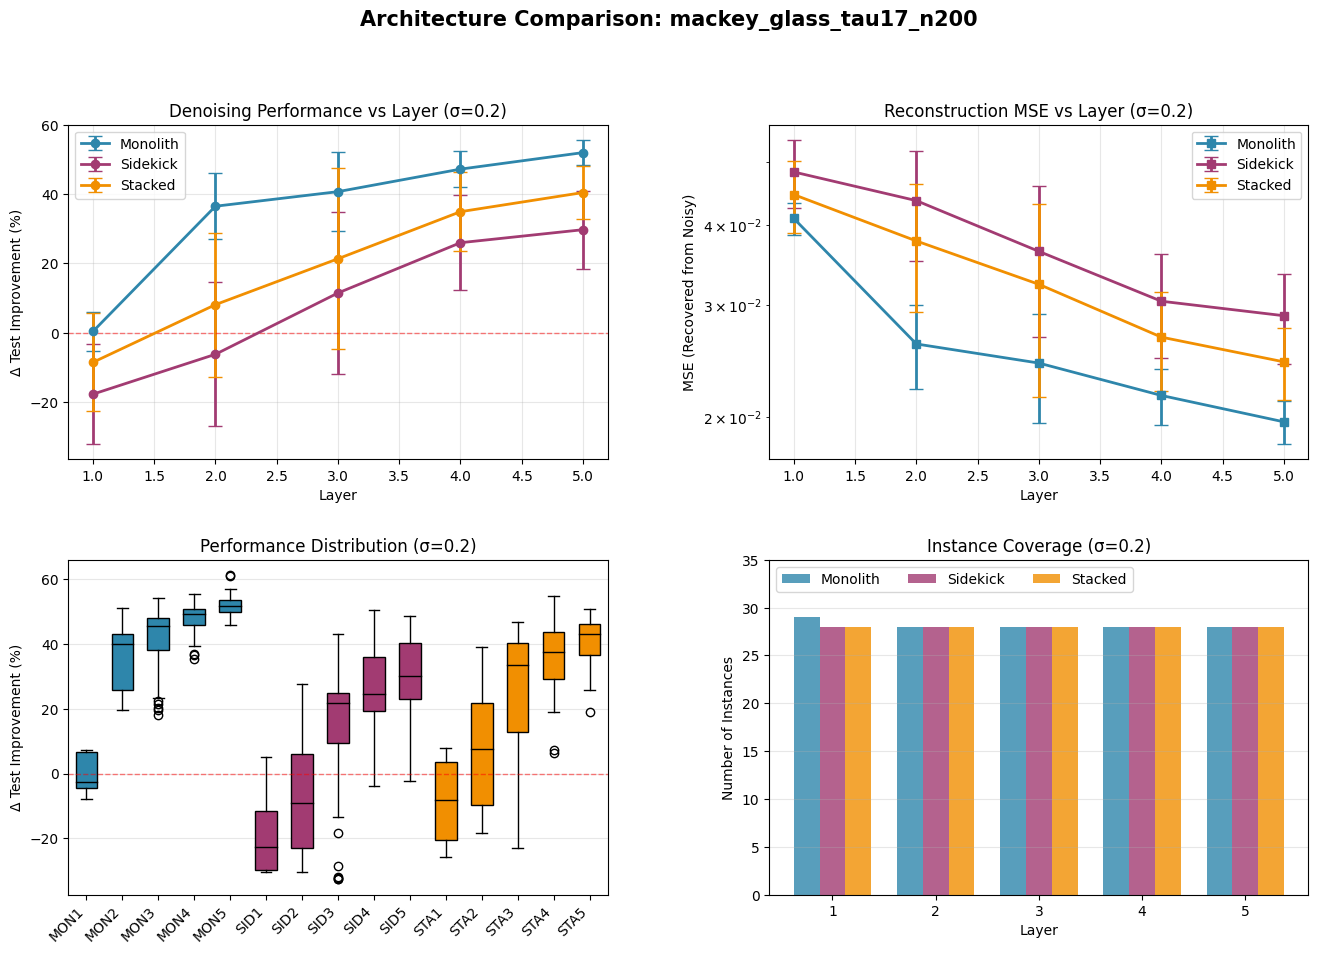

Saved comparison plot: eval_results_L4/comparison_mackey_glass_tau30_n200_sigma0.20.png


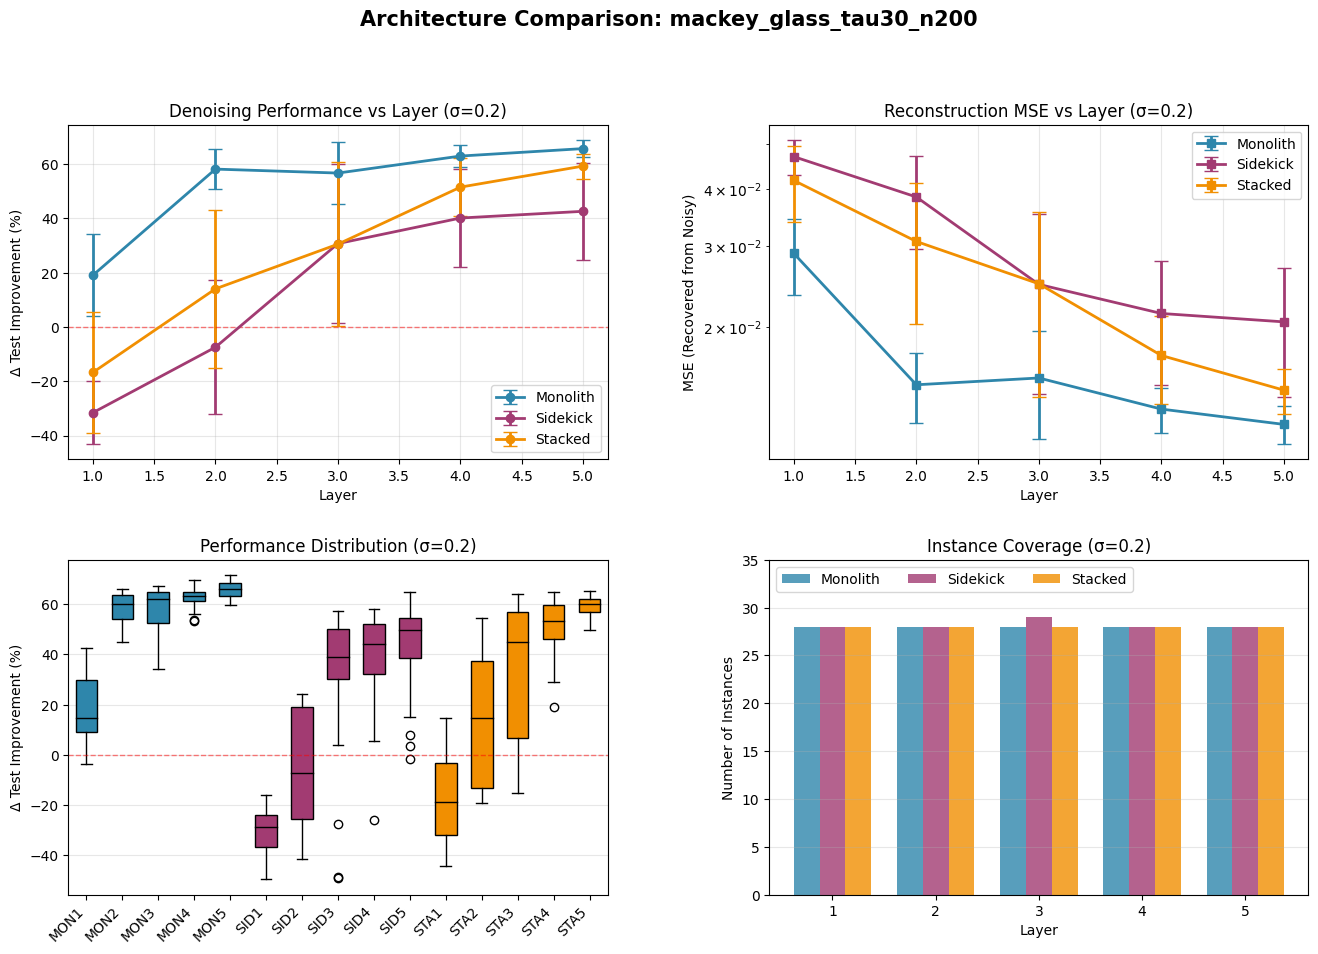

Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_2l_2t_L1_inst2_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_2l_2t_L2_inst7_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_2l_2t_L3_inst6_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_2l_2t_L4_inst6_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_2l_2t_L5_inst6_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_3l_1t_L1_inst3_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_3l_1t_L2_inst3_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_3l_1t_L3_inst3_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_3l_1t_L4_inst6_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_4q_3l_1t_L5_inst2_sigma0.20_noisy.png
Saved plots for: repr_mackey_glass_tau17_n200_monolith_6q_2l_4t_L1_ins

In [11]:
# Main Execution

def run_framework():
    """Main execution: discover, evaluate, aggregate, visualize."""
    
    print("\n--- UNIVERSAL QAE EVALUATION FRAMEWORK ---\n")
    
    all_results = []
    dataset_cache: Dict[str, np.ndarray] = {}
    
    for dataset_id in DATASETS:
        print(f"\n--- DATASET: {dataset_id} ---")
        
        try:
            y_data, data_info = load_dataset(dataset_id)
            dataset_cache[dataset_id] = y_data
            print(f"Loaded {len(y_data)} samples from: {data_info['folder']}")
        except FileNotFoundError as e:
            print(f"{e}")
            continue
        
        bundles = find_bundles_for_dataset(dataset_id)
        total_bundles = sum(len(v) for v in bundles.values())
        print(f"Found {total_bundles} bundles:")
        for arch_type, paths in bundles.items():
            print(f"  {arch_type.capitalize()}: {len(paths)}")
        
        if total_bundles == 0:
            print(f"No bundles found for {dataset_id}, skipping.")
            continue
        
        print("Evaluating bundles...")
        for arch_type, bundle_paths in bundles.items():
            for bundle_path in sorted(bundle_paths):
                try:
                    result = evaluate_bundle(bundle_path, y_data)
                    all_results.append(result)
                except Exception as e:
                    print(f"  Error while evaluating {bundle_path.name}: {e}")
                    continue
    
    if len(all_results) == 0:
        print("\nNo results collected. Exiting.")
        return None
    
    print("\n--- AGGREGATING RESULTS ---")
    
    dfs = aggregate_results_by_architecture(all_results)
    
    for arch_type, df in dfs.items():
        out_path = Path(FRAMEWORK_OUT) / f"{arch_type}_raw_results.csv"
        df.to_csv(out_path, index=False)
        print(f"Saved raw results: {out_path}")
    
    median_models_by_arch: Dict[str, pd.DataFrame] = {}
    for arch_type, df in dfs.items():
        stats = compute_architecture_statistics(df)
        out_stats = Path(FRAMEWORK_OUT) / f"{arch_type}_statistics.csv"
        stats.to_csv(out_stats, index=False)
        print(f"Saved statistics: {out_stats}")
        
        reps = find_representative_models(df)
        out_reps = Path(FRAMEWORK_OUT) / f"{arch_type}_representative_models.csv"
        reps.to_csv(out_reps, index=False)
        median_models_by_arch[arch_type] = reps
        print(f"Saved representative models: {out_reps}")
    
    if MAKE_PLOTS:
        print("\n--- GENERATING PLOTS ---")
        
        for dataset_id in DATASETS:
            for noise_level in TEST_NOISE_LEVELS:
                plot_path = Path(FRAMEWORK_OUT) / f"comparison_{dataset_id}_sigma{noise_level:.2f}.png"
                try:
                    plot_architecture_comparison(dfs, dataset_id, noise_level, plot_path)
                except Exception as e:
                    print(f"Comparison plot failed for {dataset_id}, σ={noise_level}: {e}")
        
        try:
            plot_representative_reconstructions(
                all_results, median_models_by_arch, dataset_cache,
                Path(FRAMEWORK_OUT) / "representatives"
            )
        except Exception as e:
            print(f"Representative plots failed: {e}")
    
    print("\n--- FRAMEWORK COMPLETE ---")
    print(f"Results saved to: {FRAMEWORK_OUT}")
    
    return dfs


# Execute
results_dfs = run_framework()

Using results currently in memory.
Datasets eligible for plotting: {'mackey_glass_tau30_n200', 'mackey_glass_tau17_n200'}
Generating efficiency plot for mackey_glass_tau30_n200 (σ=0.2)...


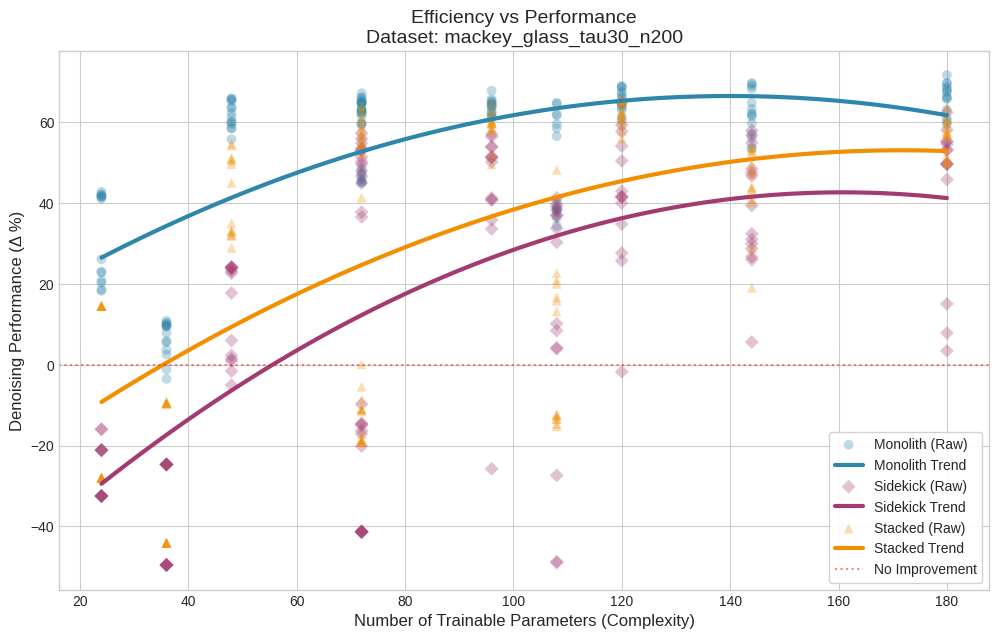

Generating efficiency plot for mackey_glass_tau17_n200 (σ=0.2)...


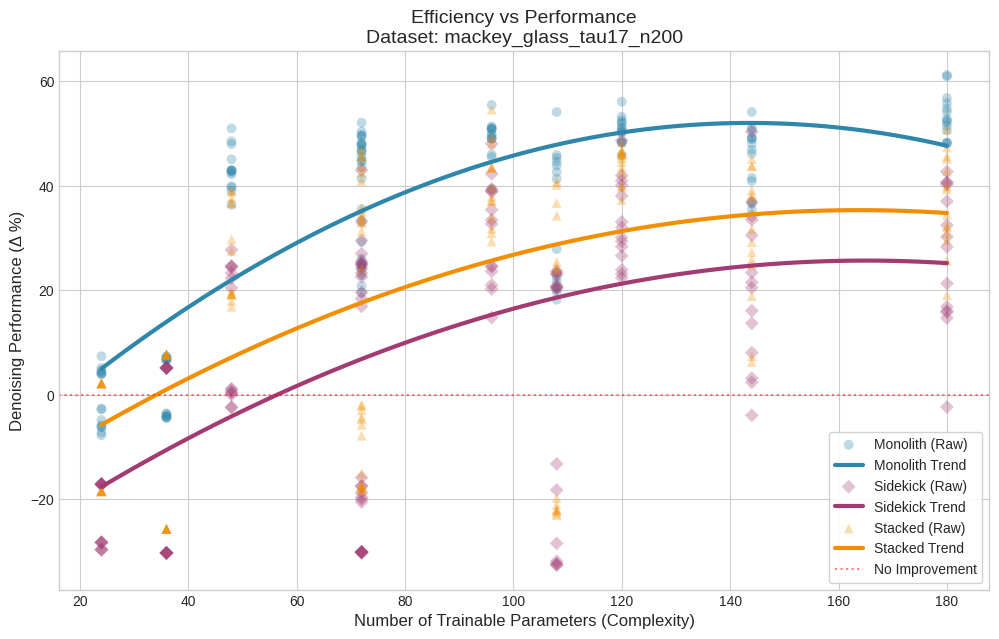

In [12]:
# Efficiency vs Performance Plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def calculate_parameter_count(arch_type, n_latent, n_trash, n_extra, n_layers, rot):
    """Calculate the number of trainable parameters based on wires used in entanglers."""
    params_per_qubit_per_layer = 1 if rot == 'Ry' else 3
    
    if arch_type == "monolith":
        n_entangling_wires = n_latent + n_trash + n_extra
        return 2 * n_layers * n_entangling_wires * params_per_qubit_per_layer
    elif arch_type in ["sidekick", "stacked"]:
        n_entangling_wires = n_latent + n_trash
        return 2 * n_layers * n_entangling_wires * params_per_qubit_per_layer
    return 0


def plot_efficiency_vs_performance_standalone(dfs, dataset_id, noise_level):
    print(f"Generating efficiency plot for {dataset_id} (σ={noise_level})...")
    
    plt.figure(figsize=(12, 7))
    try:
        plt.style.use('seaborn-v0_8-whitegrid')
    except:
        plt.grid(True, alpha=0.3)
    
    colors = {"monolith": "#2E86AB", "sidekick": "#A23B72", "stacked": "#F18F01"}
    markers = {"monolith": "o", "sidekick": "D", "stacked": "^"}
    
    found_data = False
    
    for arch_type, df in dfs.items():
        df["dataset"] = df["dataset"].astype(str)
        df["test_noise"] = df["test_noise"].astype(float)
        
        mask = (df["dataset"] == dataset_id) & (np.isclose(df["test_noise"], noise_level))
        subset = df[mask].copy()
        
        if len(subset) == 0:
            continue
        
        found_data = True
            
        subset['num_params'] = subset.apply(
            lambda row: calculate_parameter_count(
                arch_type, 
                int(row['n_latent']), int(row['n_trash']),
                int(row.get('n_extra', 0)), int(row['layer']),
                row.get('rot', 'Rxyz')
            ), axis=1
        )
        
        subset = subset[subset['delta_test_pct'] > -50]

        x = subset['num_params'].values
        y = subset['delta_test_pct'].values
        
        plt.scatter(
            x, y,
            label=f"{arch_type.capitalize()} (Raw)",
            color=colors.get(arch_type, 'gray'),
            marker=markers.get(arch_type, 'o'),
            alpha=0.3, edgecolors='none', s=50
        )
        
        if len(x) > 3:
            idx = np.argsort(x)
            x_sorted, y_sorted = x[idx], y[idx]
            z = np.polyfit(x_sorted, y_sorted, 2)
            p = np.poly1d(z)
            x_lin = np.linspace(x_sorted.min(), x_sorted.max(), 100)
            plt.plot(x_lin, p(x_lin), 
                     color=colors.get(arch_type, 'gray'), 
                     linestyle='-', linewidth=3, 
                     label=f"{arch_type.capitalize()} Trend")

    if not found_data:
        print(f"No data found for {dataset_id} at noise {noise_level}")
        plt.close()
        return

    plt.xlabel("Number of Trainable Parameters (Complexity)", fontsize=12)
    plt.ylabel("Denoising Performance (Δ %)", fontsize=12)
    plt.title(f"Efficiency vs Performance\nDataset: {dataset_id}", fontsize=14)
    plt.axhline(0, color='red', linestyle=':', alpha=0.5, label="No Improvement")
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='lower right', frameon=True, framealpha=0.9)
    plt.show()


# Load data
dfs_to_plot = {}

if 'results_dfs' in globals() and results_dfs:
    print("Using results currently in memory.")
    dfs_to_plot = results_dfs
else:
    print(f"Searching for CSVs in: {Path(FRAMEWORK_OUT).resolve()}")
    for arch in ["monolith", "sidekick", "stacked"]:
        csv_path = Path(FRAMEWORK_OUT) / f"{arch}_raw_results.csv"
        if csv_path.exists():
            dfs_to_plot[arch] = pd.read_csv(csv_path)
            print(f"  Loaded {arch}: {len(dfs_to_plot[arch])} rows")
        else:
            print(f"  Missing: {csv_path.name}")

# Generate plots
if dfs_to_plot:
    available_datasets = set()
    for df in dfs_to_plot.values():
        available_datasets.update(df['dataset'].unique())
    
    print(f"Datasets eligible for plotting: {available_datasets}")
    for d_id in available_datasets:
        plot_efficiency_vs_performance_standalone(dfs_to_plot, d_id, 0.2)
else:
    print("ERROR: No data found. Please run the full framework evaluation cell first.")

In [13]:
# Summary Analysis

def print_summary(dfs: Dict[str, pd.DataFrame]):
    """Print high-level summary of results."""
    
    print("\n--- SUMMARY REPORT ---\n")
    
    for arch_type, df in dfs.items():
        print(f"{arch_type.upper()}")
        print(f"  Total evaluations: {len(df)}")
        print(f"  Datasets: {df['dataset'].nunique()}")
        print(f"  Unique architectures: {df.groupby(['n_qubits', 'n_latent', 'n_trash']).ngroups}")
        print(f"  Layer range: {df['layer'].min()} - {df['layer'].max()}")
        print(f"  Instance count: {df['instance_id'].nunique()}")
        
        print(f"\n  Performance (mean ± std) by noise:")
        for noise in sorted(df['test_noise'].unique()):
            noise_df = df[df['test_noise'] == noise]
            delta_mean = noise_df['delta_test_pct'].mean()
            delta_std = noise_df['delta_test_pct'].std()
            mse_mean = noise_df['mse_test_recovered_noisy'].mean()
            qmi_mean = noise_df.get('qmi_test', pd.Series([np.nan])).mean()
            print(f"    σ={noise:.2f}: Δ={delta_mean:+.2f}±{delta_std:.2f}%, "
                  f"MSE_rec={mse_mean:.6f}, QMI={qmi_mean:.3f}")
        
        print(f"\n  Best single model (by Δ_test_pct):")
        best = df.loc[df['delta_test_pct'].idxmax()]
        print(f"    Dataset: {best['dataset']}, Layer: {best['layer']}, Instance: {best['instance_id']}")
        print(f"    σ={best['test_noise']:.2f}, Δ={best['delta_test_pct']:+.2f}%, QMI={best.get('qmi_test', np.nan):.3f}")
        print()

if results_dfs:
    print_summary(results_dfs)


--- SUMMARY REPORT ---

MONOLITH
  Total evaluations: 281
  Datasets: 2
  Unique architectures: 4
  Layer range: 1 - 5
  Instance count: 7

  Performance (mean ± std) by noise:
    σ=0.20: Δ=+43.79±21.54%, MSE_rec=0.021810, QMI=0.755

  Best single model (by Δ_test_pct):
    Dataset: mackey_glass_tau30_n200, Layer: 5, Instance: 1
    σ=0.20, Δ=+71.62%, QMI=0.000

SIDEKICK
  Total evaluations: 281
  Datasets: 2
  Unique architectures: 4
  Layer range: 1 - 5
  Instance count: 7

  Performance (mean ± std) by noise:
    σ=0.20: Δ=+11.82±31.24%, MSE_rec=0.033922, QMI=0.460

  Best single model (by Δ_test_pct):
    Dataset: mackey_glass_tau30_n200, Layer: 5, Instance: 6
    σ=0.20, Δ=+64.87%, QMI=2.276

STACKED
  Total evaluations: 280
  Datasets: 2
  Unique architectures: 4
  Layer range: 1 - 5
  Instance count: 7

  Performance (mean ± std) by noise:
    σ=0.20: Δ=+23.49±30.50%, MSE_rec=0.029480, QMI=0.387

  Best single model (by Δ_test_pct):
    Dataset: mackey_glass_tau30_n200, Layer:


--- GENERATING ARTIFACTS for mackey_glass_tau30_n200 ---

  Monolith Repr: Layer 5, Instance 3 (6q_4l_2t) -> Δ = 68.67% (Group Mean: 68.46%)
  Sidekick Repr: Layer 5, Instance 1 (6q_4l_2t) -> Δ = 52.98% (Group Mean: 53.40%)
  Stacked Repr: Layer 5, Instance 7 (4q_3l_1t) -> Δ = 62.15% (Group Mean: 62.19%)


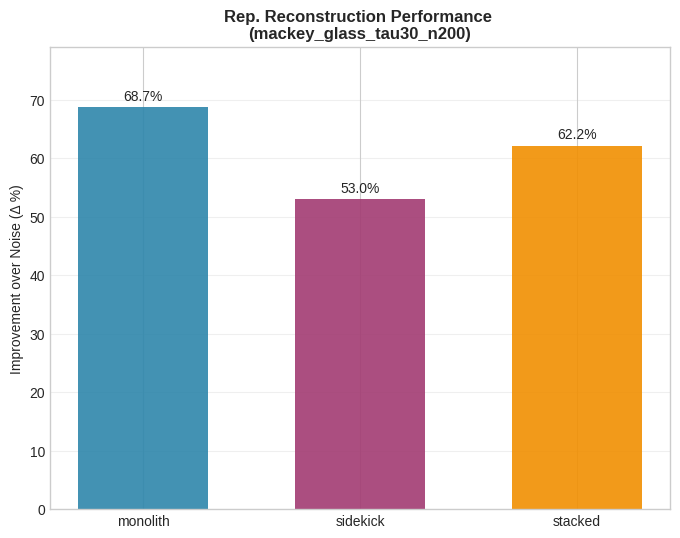

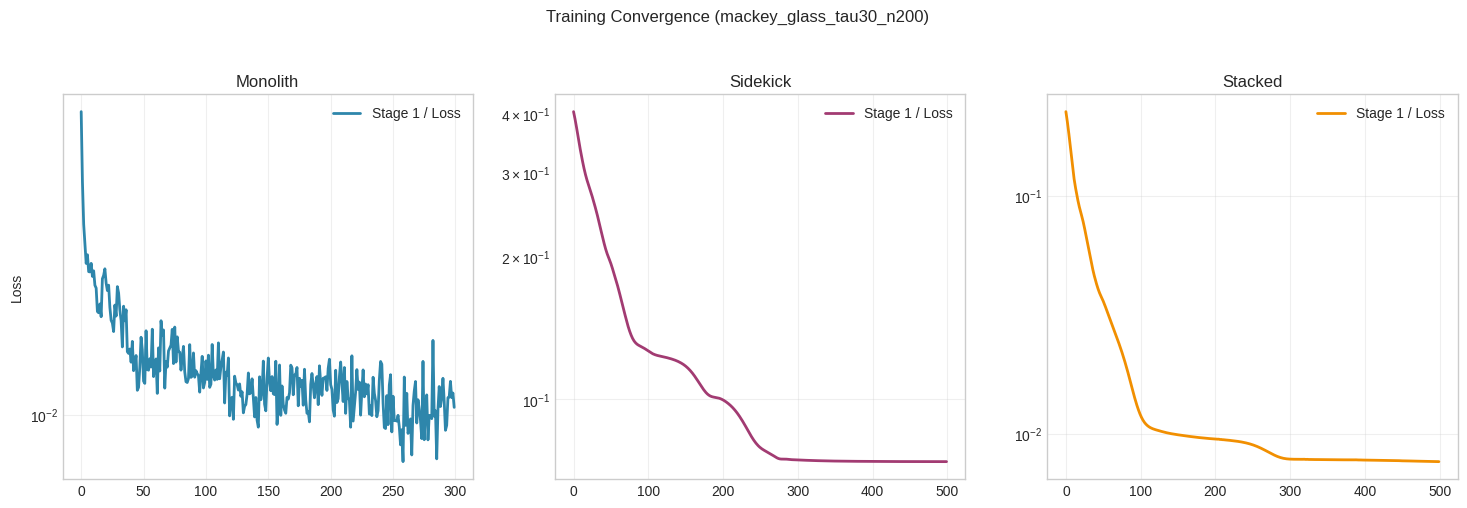

Calculating average training times...
Searching Monolith in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Monolith_QAE/qae_runs/mackey_glass_tau30_n200
  Found 140 bundles for monolith (skipped 14 timing/retraining/mirror)
Searching Sidekick in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Sidekick_QAE/qae_runs/mackey_glass_tau30_n200
  Found 141 bundles for sidekick (skipped 154 timing/retraining/mirror)
Searching Stacked in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Stacked_QAE/qae_runs/mackey_glass_tau30_n200
  Found 140 bundles for stacked (skipped 225 timing/retraining/mirror)


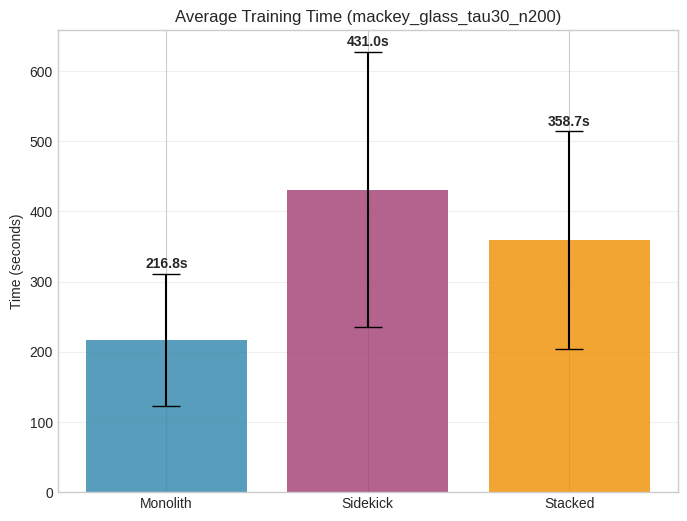

Artifact generation complete.


In [14]:
# Paper Artifacts (τ=30)

def generate_paper_artifacts(dfs: Dict[str, pd.DataFrame], dataset_id: str):
    """
    Generate final artifacts:
    1. Performance Comparison of the single best model per architecture.
    2. Training Process visualization.
    3. Average Training Time analysis.
    """
    print(f"\n--- GENERATING ARTIFACTS for {dataset_id} ---\n")
    
    # 1. Identify representative champions (Best Config -> Median Instance)
    best_models = {}
    
    for arch in ['monolith', 'sidekick', 'stacked']:
        if arch not in dfs:
            continue
            
        df = dfs[arch]
        df_ds = df[df['dataset'] == dataset_id]
        if len(df_ds) == 0:
            continue
            
        noise_levels = sorted(df_ds['test_noise'].unique())
        if not noise_levels: continue
        target_noise = noise_levels[0]
        df_noise = df_ds[df_ds['test_noise'] == target_noise]

        config_cols = ['n_qubits', 'n_latent', 'n_trash', 'layer']
        grouper = df_noise.groupby(config_cols)['delta_test_pct']
        best_config_vals = grouper.mean().idxmax()
        
        mask = pd.Series([True]*len(df_noise), index=df_noise.index)
        for col, val in zip(config_cols, best_config_vals):
            mask &= (df_noise[col] == val)
        
        candidates = df_noise[mask]
        mean_score = candidates['delta_test_pct'].mean()
        best_idx = (candidates['delta_test_pct'] - mean_score).abs().idxmin()
        best_row = candidates.loc[best_idx]
        
        best_models[arch] = {"row": best_row, "bundle_path": Path(best_row['bundle_path'])}
        
        print(f"  {arch.capitalize()} Repr: Layer {best_row['layer']}, "
              f"Instance {best_row['instance_id']} "
              f"({best_row['n_qubits']}q_{best_row['n_latent']}l_{best_row['n_trash']}t) "
              f"-> Δ = {best_row['delta_test_pct']:.2f}% (Group Mean: {mean_score:.2f}%)")

    if not best_models:
        print("No models found to analyze.")
        return

    # 2. Extract training history & time
    def extract_training_details(path):
        path = Path(path)
        try:
            with open(path, 'r') as f:
                b = json.load(f)
        except Exception:
            return [], [], 0.0, 0.0

        run = b.get("run", {})
        t1, t2 = 0.0, 0.0
        
        for k in ["stage1_time_sec", "time_stage1", "time_unfrozen"]:
            if k in run and run[k] is not None:
                t1 = float(run[k])
                break
        
        for k in ["stage2_time_sec", "time_stage2"]:
            if k in run and run[k] is not None:
                t2 = float(run[k])
                break
                
        if t1 == 0.0 and t2 == 0.0:
            for k in ["training_time_sec", "time_total", "elapsed_time"]:
                if k in run and run[k] is not None:
                    t1 = float(run[k])
                    break

        h1 = run.get("history_stage1") or run.get("cost_history") or run.get("history") or []
        h2 = run.get("history_stage2") or run.get("history_unfrozen") or []
        
        if not h1:
            layer, inst = run.get("layer"), run.get("instance_id")
            if layer is not None and inst is not None:
                parent = path.parent
                candidates = list(parent.glob(f"cost_*inst*{inst}*L{layer}*.json"))
                if candidates:
                    try:
                        with open(candidates[0], 'r') as f:
                            c_data = json.load(f)
                            if isinstance(c_data, list): h1 = c_data
                            elif isinstance(c_data, dict):
                                h1 = c_data.get("history_stage1") or c_data.get("cost_history") or []
                                if not h2: h2 = c_data.get("history_stage2") or []
                    except: pass
        
        if h1 is None: h1 = []
        if h2 is None: h2 = []
        h1 = [x[0] if isinstance(x, list) and len(x) > 0 else x for x in h1]
        h2 = [x[0] if isinstance(x, list) and len(x) > 0 else x for x in h2]

        return h1, h2, t1, t2

    champion_data = {}
    for arch, info in best_models.items():
        h1, h2, t1, t2 = extract_training_details(info['bundle_path'])
        champion_data[arch] = {"h1": h1, "h2": h2, "t1": t1, "t2": t2, "meta": info['row']}

    # 3. Plot: Performance Comparison
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    archs = [a for a in ['monolith', 'sidekick', 'stacked'] if a in champion_data]
    deltas = [champion_data[a]['meta']['delta_test_pct'] for a in archs]
    colors_map = {"monolith": "#2E86AB", "sidekick": "#A23B72", "stacked": "#F18F01"}
    
    bars = ax1.bar(archs, deltas, color=[colors_map[a] for a in archs], alpha=0.9, width=0.6)
    ax1.set_ylabel("Improvement over Noise (Δ %)")
    ax1.set_title(f"Rep. Reconstruction Performance \n({dataset_id})", fontweight='bold')
    ax1.bar_label(bars, fmt='%.1f%%', padding=3)
    ax1.set_ylim(bottom=0, top=max(deltas)*1.15)
    ax1.grid(axis='y', alpha=0.3)
    plt.show()

    # 4. Plot: Training Landscapes
    fig2, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, arch in enumerate(['monolith', 'sidekick', 'stacked']):
        ax = axes[i]
        if arch in champion_data:
            data = champion_data[arch]
            h1, h2 = np.array(data['h1']), np.array(data['h2'])
            c = colors_map[arch]
            if len(h1) > 0:
                ax.plot(h1, label="Stage 1 / Loss", color=c, linewidth=2)
            if len(h2) > 0:
                ax.plot(np.arange(len(h1), len(h1)+len(h2)), h2, label="Stage 2", color=c, linestyle="--")
            ax.set_title(arch.capitalize())
            if i == 0: ax.set_ylabel("Loss")
            ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend()
        else:
            ax.set_visible(False)
    plt.suptitle(f"Training Convergence ({dataset_id})", y=1.05)
    plt.show()

    # 5. Average Training Time
    print("Calculating average training times...")
    time_stats = defaultdict(list)
    all_bundles = find_bundles_for_dataset(dataset_id)
    
    for arch, paths in all_bundles.items():
        for p in paths:
            try:
                _, _, t1, t2 = extract_training_details(p)
                if (t1 + t2) > 0.1: time_stats[arch].append(t1 + t2)
            except: pass
    
    means, stds, labels = [], [], []
    for arch in ['monolith', 'sidekick', 'stacked']:
        times = np.array(time_stats[arch])
        if len(times) > 0:
            means.append(np.mean(times))
            stds.append(np.std(times))
            labels.append(arch.capitalize())

    if labels:
        plt.figure(figsize=(8, 6))
        plt.bar(labels, means, yerr=stds, capsize=10, color=[colors_map.get(l.lower(), 'gray') for l in labels], alpha=0.8)
        for i, v in enumerate(means):
            plt.text(i, v + stds[i] + max(means)*0.02, f"{v:.1f}s", ha='center', fontweight='bold')
        plt.ylabel("Time (seconds)")
        plt.title(f"Average Training Time ({dataset_id})")
        plt.grid(axis='y', alpha=0.3)
        plt.show()
    
    print("Artifact generation complete.")

if DATASETS and results_dfs:
    generate_paper_artifacts(results_dfs, DATASETS[1])


--- GENERATING ARTIFACTS for mackey_glass_tau17_n200 ---

  Monolith Repr: 6q_4l_2t L5 (inst 6) -> Δ=56.80%
  Sidekick Repr: 6q_4l_2t L5 (inst 2) -> Δ=37.05%
  Stacked Repr: 4q_3l_1t L4 (inst 7) -> Δ=43.65%


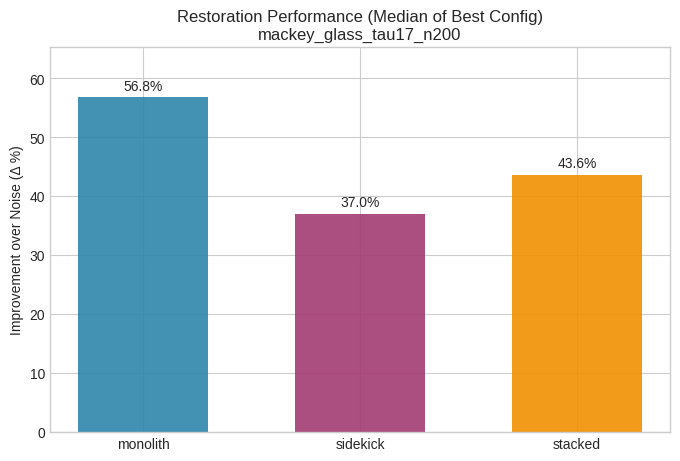

--- TRAINING VISUALIZATION ---

  Monolith (L5, Inst 6)
   (EPS files found at /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Monolith_QAE/qae_runs/mackey_glass_tau17_n200/6q_4l_2t/L5, cannot display inline.)
   Generating live plot from data...


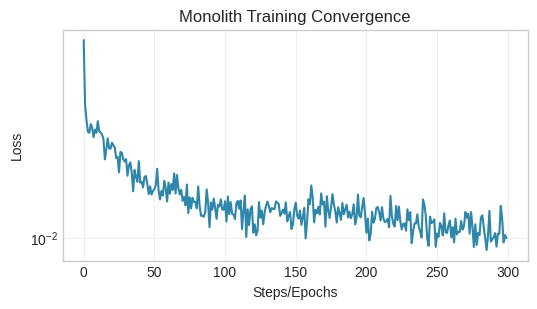


  Sidekick (L5, Inst 2)
   (EPS files found at /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Sidekick_QAE/qae_runs/mackey_glass_tau17_n200/6q_4l_2t_sidekick/L5, cannot display inline.)
   Generating live plot from data...


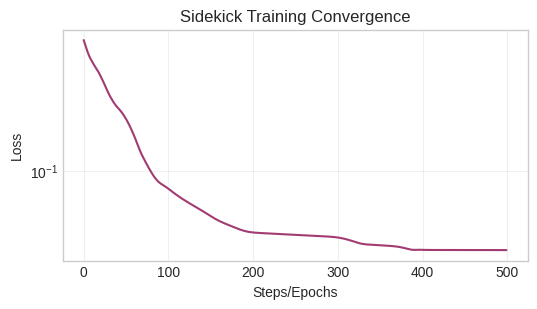


  Stacked (L4, Inst 7)
   (EPS files found at /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Stacked_QAE/qae_runs/mackey_glass_tau17_n200/4q_3l_1t_stacked/L4, cannot display inline.)
   Generating live plot from data...


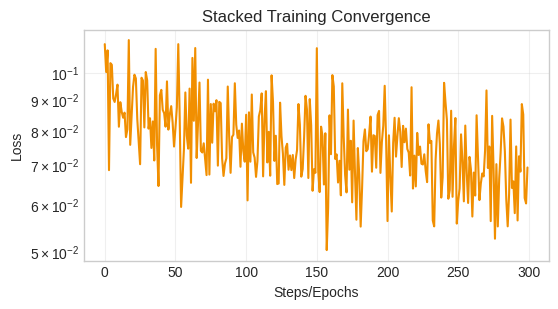


Calculating average training times...
Searching Monolith in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Monolith_QAE/qae_runs/mackey_glass_tau17_n200
  Found 141 bundles for monolith
Searching Sidekick in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Sidekick_QAE/qae_runs/mackey_glass_tau17_n200
  Found 140 bundles for sidekick
Searching Stacked in: /home/jacob/Dropbox/Dev/Python/quantum_projects/ts_qae_denosing/ts_qae_denoise_pl/dev/Stacked_QAE/qae_runs/mackey_glass_tau17_n200
  Found 140 bundles for stacked


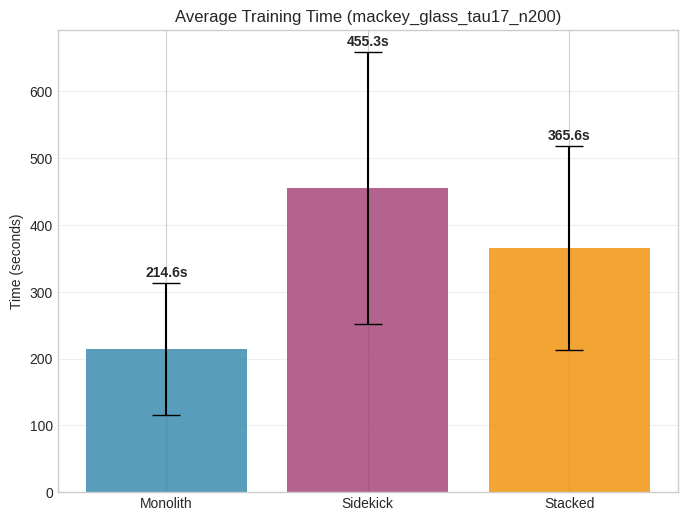

Artifact generation complete.


In [15]:
# Paper Artifacts (τ=17)
from IPython.display import Image, display

def generate_paper_artifacts(dfs: Dict[str, pd.DataFrame], dataset_id: str):
    """
    Generate final artifacts:
    1. Performance Comparison (Best Config -> Median Instance)
    2. Training Process visualization (Image file -> data fallback)
    3. Average Training Time analysis.
    """
    print(f"\n--- GENERATING ARTIFACTS for {dataset_id} ---\n")
    
    # 1. Identify representative champions
    best_models = {}
    
    for arch in ['monolith', 'sidekick', 'stacked']:
        if arch not in dfs: continue
        df = dfs[arch]
        df_ds = df[df['dataset'] == dataset_id]
        if len(df_ds) == 0: continue
            
        noise_levels = sorted(df_ds['test_noise'].unique())
        if not noise_levels: continue
        target_noise = noise_levels[0]
        df_noise = df_ds[df_ds['test_noise'] == target_noise]

        config_cols = ['n_qubits', 'n_latent', 'n_trash', 'layer']
        grouper = df_noise.groupby(config_cols)['delta_test_pct']
        if grouper.ngroups == 0: continue
        
        best_config_vals = grouper.mean().idxmax()
        mask = pd.Series([True]*len(df_noise), index=df_noise.index)
        for col, val in zip(config_cols, best_config_vals):
            mask &= (df_noise[col] == val)
        candidates = df_noise[mask]
        
        mean_score = candidates['delta_test_pct'].mean()
        best_idx = (candidates['delta_test_pct'] - mean_score).abs().idxmin()
        best_row = candidates.loc[best_idx]
        
        best_models[arch] = {"row": best_row, "bundle_path": Path(best_row['bundle_path'])}
        
        print(f"  {arch.capitalize()} Repr: {best_row['n_qubits']}q_{best_row['n_latent']}l_{best_row['n_trash']}t "
              f"L{best_row['layer']} (inst {best_row['instance_id']}) -> Δ={best_row['delta_test_pct']:.2f}%")

    if not best_models:
        print("No models found to analyze.")
        return

    # 2. Plot: Performance Comparison
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    archs = [a for a in ['monolith', 'sidekick', 'stacked'] if a in best_models]
    deltas = [best_models[a]['row']['delta_test_pct'] for a in archs]
    colors = {"monolith": "#2E86AB", "sidekick": "#A23B72", "stacked": "#F18F01"}
    
    bars = ax1.bar(archs, deltas, color=[colors[a] for a in archs], alpha=0.9, width=0.6)
    ax1.bar_label(bars, fmt='%.1f%%', padding=3)
    ax1.set_title(f"Restoration Performance (Median of Best Config)\n{dataset_id}")
    ax1.set_ylabel("Improvement over Noise (Δ %)")
    ax1.set_ylim(0, max(deltas)*1.15)
    plt.show()

    # 3. Training Visualization (Image file -> data fallback)
    print("--- TRAINING VISUALIZATION ---")

    def extract_history(path):
        try:
            with open(path, 'r') as f: run = json.load(f).get("run", {})
            h1 = run.get("history_stage1") or run.get("cost_history") or run.get("history") or []
            h2 = run.get("history_stage2") or run.get("history_unfrozen") or []
            
            if not h1:
                layer, inst = run.get("layer"), run.get("instance_id")
                if layer is not None:
                    candidates = list(path.parent.glob(f"cost_*inst*{inst}*L{layer}*.json"))
                    if candidates:
                        with open(candidates[0], 'r') as f:
                            c = json.load(f)
                            if isinstance(c, list): h1 = c
                            elif isinstance(c, dict): 
                                h1 = c.get("history_stage1") or c.get("cost_history")
                                h2 = c.get("history_stage2")
            
            def cln(h): return [x[0] if isinstance(x, list) else x for x in (h or [])]
            return cln(h1), cln(h2)
        except: return [], []

    for arch, info in best_models.items():
        row = info['row']
        bundle_path = info['bundle_path']
        layer = int(row['layer'])
        inst = int(row['instance_id'])
        work_dir = bundle_path.parent
        
        print(f"\n  {arch.capitalize()} (L{layer}, Inst {inst})")
        
        found_img = False
        img_patterns = []
        if arch == "monolith":
            img_patterns = [f"training_cost_inst{inst:02d}_L{layer}.png"]
        else:
            img_patterns = [f"training_cost_s1_inst{inst:02d}_L{layer}.png", 
                            f"training_cost_s2_inst{inst:02d}_L{layer}.png"]
            
        for pat in img_patterns:
            f = work_dir / pat
            if f.exists():
                display(Image(filename=str(f), width=500))
                found_img = True
        
        if not found_img:
            eps_found = list(work_dir.glob("*.eps"))
            if eps_found:
                print(f"   (EPS files found at {work_dir}, cannot display inline.)")
            
            print("   Generating live plot from data...")
            h1, h2 = extract_history(bundle_path)
            if not h1 and not h2:
                print("   (No training history found.)")
                continue
                
            plt.figure(figsize=(6, 3))
            c = colors.get(arch, 'blue')
            if h1: plt.plot(h1, label="Stage 1", color=c)
            if h2: plt.plot(np.arange(len(h1), len(h1)+len(h2)), h2, label="Stage 2", color=c, linestyle="--", alpha=0.7)
            plt.yscale('log')
            plt.title(f"{arch.capitalize()} Training Convergence")
            plt.ylabel("Loss"); plt.xlabel("Steps/Epochs")
            plt.grid(True, alpha=0.3)
            plt.show()

    # 4. Average Training Time
    def extract_time_robust(path):
        try:
            with open(path, 'r') as f: b = json.load(f).get("run", {})
            for k in ["training_time_sec", "time_total", "elapsed_time"]:
                if b.get(k): return float(b[k])
            t1 = float(b.get("stage1_time_sec") or b.get("time_stage1") or b.get("time_unfrozen") or 0)
            t2 = float(b.get("stage2_time_sec") or b.get("time_stage2") or 0)
            return t1 + t2
        except: return 0.0

    print("\nCalculating average training times...")
    time_groups = defaultdict(list)
    bundles = find_bundles_for_dataset(dataset_id)
    
    for arch, paths in bundles.items():
        for p in paths:
            t = extract_time_robust(p)
            if t > 0.5: time_groups[arch].append(t)

    if any(time_groups.values()):
        means, stds, labels = [], [], []
        for arch in ['monolith', 'sidekick', 'stacked']:
            ts = time_groups[arch]
            if ts:
                means.append(np.mean(ts))
                stds.append(np.std(ts))
                labels.append(arch.capitalize())
    if labels:
        plt.figure(figsize=(8, 6))
        plt.bar(labels, means, yerr=stds, capsize=10, color=[colors.get(l.lower(), 'gray') for l in labels], alpha=0.8)
        for i, v in enumerate(means):
            plt.text(i, v + stds[i] + max(means)*0.02, f"{v:.1f}s", ha='center', fontweight='bold')
        plt.ylabel("Time (seconds)")
        plt.title(f"Average Training Time ({dataset_id})")
        plt.grid(axis='y', alpha=0.3)
        plt.show()
    
    print("Artifact generation complete.")

if DATASETS and results_dfs:
    generate_paper_artifacts(results_dfs, DATASETS[0])

Dataset: mackey_glass_tau30_n200 (200 pts), noise=0.2, eval_seed=99123

  Monolith: ../Monolith_QAE/qae_runs/mackey_glass_tau30_n200/6q_4l_2t_timing/L4
    bundle_dec000_enc300_inst01_L4.json  Δ_test=+61.39%
    bundle_dec000_enc300_inst02_L4.json  Δ_test=+68.07%
    bundle_dec000_enc300_inst03_L4.json  Δ_test=+68.59%
    bundle_dec000_enc300_inst04_L4.json  Δ_test=+69.36%
    bundle_dec000_enc300_inst05_L4.json  Δ_test=+70.60%
    bundle_dec000_enc300_inst06_L4.json  Δ_test=+63.22%
    bundle_dec000_enc300_inst07_L4.json  Δ_test=+68.86%

  Sidekick (frozen): ../Sidekick_QAE/qae_runs/mackey_glass_tau30_n200/6q_4l_2t_sidekick_timing/L4
    bundle_dec100_enc500_inst01_L4.json  Δ_test=+31.86%
    bundle_dec100_enc500_inst02_L4.json  Δ_test=+44.23%
    bundle_dec100_enc500_inst03_L4.json  Δ_test=+41.69%
    bundle_dec100_enc500_inst04_L4.json  Δ_test=+41.30%
    bundle_dec100_enc500_inst05_L4.json  Δ_test=+40.31%
    bundle_dec100_enc500_inst06_L4.json  Δ_test=+35.36%
    bundle_dec100_enc

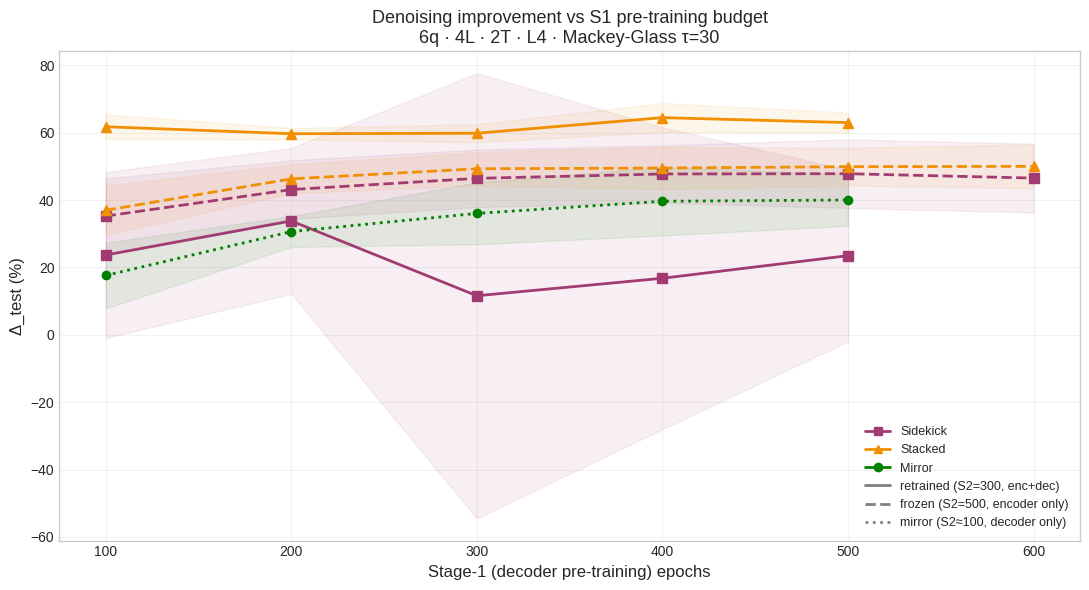

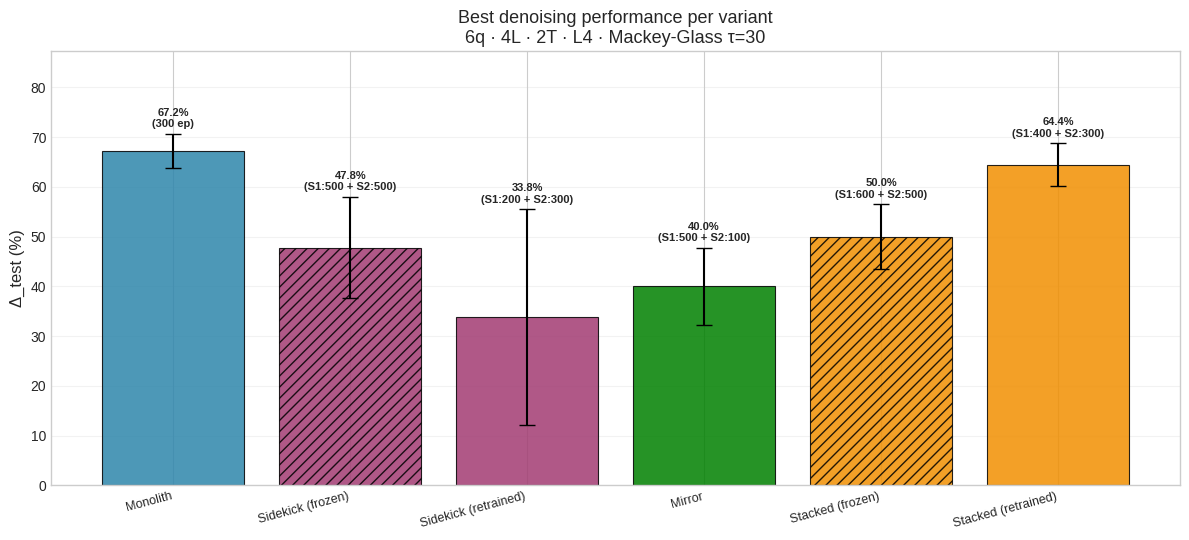

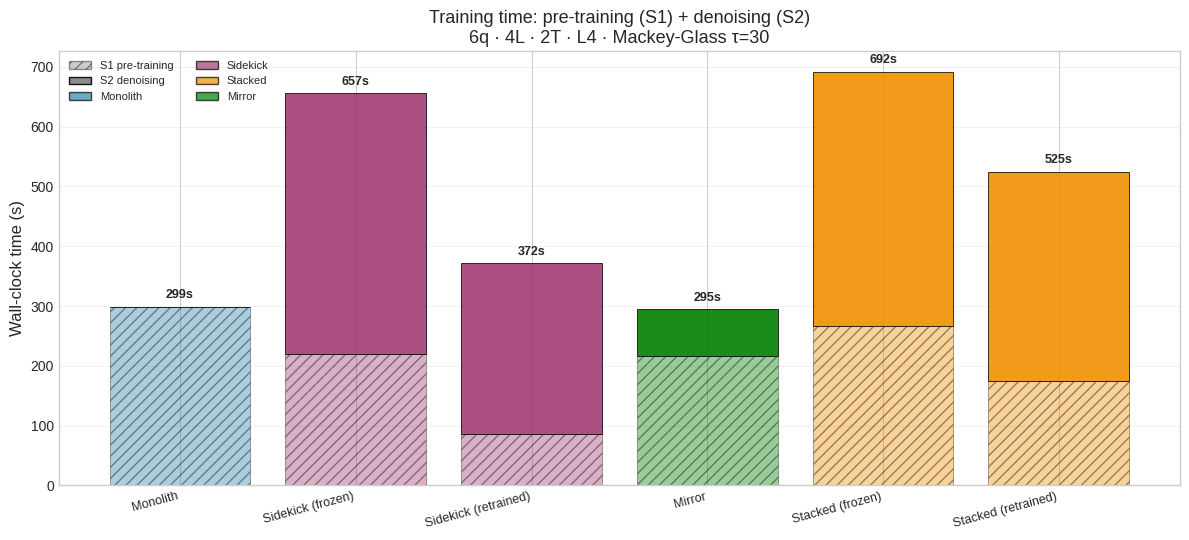

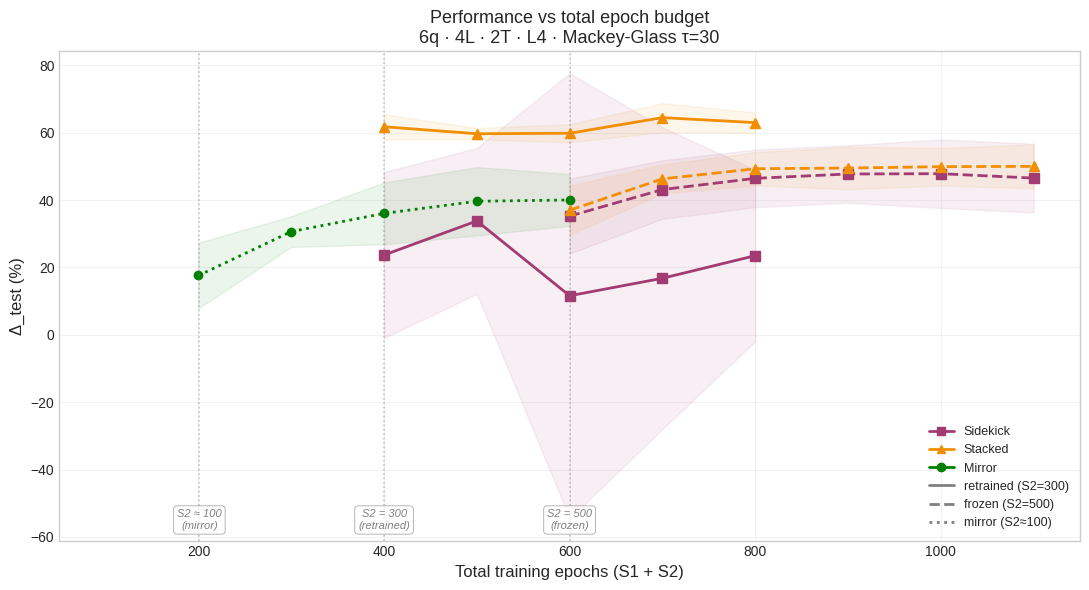


── Best configuration per variant ──

               Model                 Epochs    Δ_test (%) Time (s)
            Monolith     300 (single-stage)  67.15 ± 3.45      299
   Sidekick (frozen) S1:500 + S2:500 = 1000 47.81 ± 10.19      657
Sidekick (retrained)  S1:200 + S2:300 = 500 33.79 ± 21.66      372
              Mirror  S1:500 + S2:100 = 600  40.01 ± 7.68      295
    Stacked (frozen) S1:600 + S2:500 = 1100  49.99 ± 6.50      692
 Stacked (retrained)  S1:400 + S2:300 = 700  64.45 ± 4.31      525

Done — all metrics re-evaluated through the quantum circuit.


In [16]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

BASE = Path("../")

# Bundle field mapping (verified from training notebooks):
#   dec_epochs → S1 (decoder pre-training, VARIES across runs)
#   enc_epochs → S2 (encoder/denoising training, FIXED per variant)

SOURCES = {
    "Monolith": {
        "path": BASE / "Monolith_QAE/qae_runs/mackey_glass_tau30_n200/6q_4l_2t_timing/L4",
        "arch": "monolith", "variant": "baseline",
    },
    "Sidekick (frozen)": {
        "path": BASE / "Sidekick_QAE/qae_runs/mackey_glass_tau30_n200/6q_4l_2t_sidekick_timing/L4",
        "arch": "sidekick", "variant": "frozen",
    },
    "Sidekick (retrained)": {
        "path": BASE / "Sidekick_QAE/qae_runs/mackey_glass_tau30_n200/6q_4l_2t_sidekick_retraining/L4",
        "arch": "sidekick", "variant": "retrained",
    },
    "Mirror": {
        "path": BASE / "Stacked_QAE/qae_runs/mackey_glass_tau30_n200/6q_4l_2t_stacked_mirror/L4",
        "arch": "stacked", "variant": "mirror",
    },
    "Stacked (frozen)": {
        "path": BASE / "Stacked_QAE/qae_runs/mackey_glass_tau30_n200/6q_4l_2t_stacked_timing/L4",
        "arch": "stacked", "variant": "frozen",
    },
    "Stacked (retrained)": {
        "path": BASE / "Stacked_QAE/qae_runs/mackey_glass_tau30_n200/6q_4l_2t_stacked_retraining/L4",
        "arch": "stacked", "variant": "retrained",
    },
}

dataset_id = "mackey_glass_tau30_n200"
y_data, data_info = load_dataset(dataset_id)
noise_level = TEST_NOISE_LEVELS[0]
# Use the exact seed from training notebooks (TEST_SEED_FIXED = 99123)
# All families share this seed so comparisons are fair.
eval_seed = TEST_SEED_BASE
print(f"Dataset: {dataset_id} ({len(y_data)} pts), noise={noise_level}, eval_seed={eval_seed}")

records = []
for label, src in SOURCES.items():
    bdir = src["path"]
    if not bdir.exists():
        print(f"  ⚠ {bdir} not found"); continue
    print(f"\n  {label}: {bdir}")
    for bp in sorted(bdir.glob("bundle_*.json")):
        with open(bp) as fh:
            b = json.load(fh)
        run = b.get("run", {})
        stored = b.get("metrics", {})
        # dec_epochs = S1 (decoder pre-training), enc_epochs = S2 (encoder training)
        s1_ep = int(run.get("dec_epochs", 0))
        s2_ep = int(run.get("enc_epochs", 0))
        t_total = run.get("training_time_sec", 0)
        if not t_total:
            t_total = (run.get("stage1_time_sec", 0) or 0) + (run.get("stage2_time_sec", 0) or 0)

        config = parse_bundle(bp)

        # Mirror fix: the training notebooks evaluate Stage 3 with
        # init_weights_s2 = concat(s1, s1) — the pure mirrored decoder
        # weights — but the bundle stores opt_weights_s2 (after 1 epoch
        # of S2 training).  Reconstruct the true mirror weights here.
        if src["variant"] == "mirror":
            s1 = config["weights_s1"]
            config["weights_s2"] = np.concatenate([s1, s1], axis=0)

        model, weights = None, None
        try:
            if config["arch_type"] == "monolith":
                model, weights = build_monolith_qae(config)
            elif config["arch_type"] == "sidekick":
                model = build_sidekick_qae(config)
            elif config["arch_type"] == "stacked":
                model = build_stacked_qae(config)
            else:
                continue
            met = evaluate_model_on_noise(
                model, weights, config, y_data,
                noise_level=noise_level, seed=eval_seed, return_series=False,
            )
        except Exception as e:
            print(f"    ✗ {bp.name}: {e}"); continue

        records.append({
            "label": label, "arch": src["arch"], "variant": src["variant"],
            "s1_epochs": s1_ep, "s2_epochs": s2_ep,
            "total_epochs": s1_ep + s2_ep,
            "delta_test_pct": met["delta_test_pct"],
            "delta_train_pct": met["delta_train_pct"],
            "stored_delta_test": stored.get("delta_test_pct", np.nan),
            "training_time_sec": t_total,
            "stage1_time_sec": run.get("stage1_time_sec", 0) or 0,
            "stage2_time_sec": run.get("stage2_time_sec", 0) or 0,
        })
        print(f"    {bp.name}  Δ_test={met['delta_test_pct']:+.2f}%")

df = pd.DataFrame(records)
print(f"\n{len(df)} bundles re-evaluated across {df['label'].nunique()} variants.\n")
print(df.groupby("label").agg(
    n=("delta_test_pct","count"), mean=("delta_test_pct","mean"),
    std=("delta_test_pct","std"), best=("delta_test_pct","max"),
).round(2).to_string())

print("\n\n── Stored vs Re-evaluated Δ_test (%) ──\n")
diag = df.groupby("label").agg(
    stored=("stored_delta_test","mean"), evaluated=("delta_test_pct","mean"),
).round(2)
diag["gap"] = (diag["stored"] - diag["evaluated"]).round(2)
print(diag.to_string())

CLR = {"Monolith": "#2E86AB", "Sidekick": "#A23B72", "Stacked": "#F18F01", "Mirror": "green"}
STYLE = {
    "Monolith":              (CLR["Monolith"], "-",  "o", 8),
    # "Sidekick (mirror)":     (CLR["Sidekick"], ":",  "s", 6),
    "Sidekick (frozen)":     (CLR["Sidekick"], "--", "s", 7),
    "Sidekick (retrained)":  (CLR["Sidekick"], "-",  "s", 7),
    "Mirror":                (CLR["Mirror"],   ":",  "o", 6),
    "Stacked (frozen)":      (CLR["Stacked"],  "--", "^", 7),
    "Stacked (retrained)":   (CLR["Stacked"],  "-",  "^", 7),
}

TWO_STAGE = [
    # "Sidekick (mirror)", "Sidekick (frozen)", "Sidekick (retrained)",
    "Sidekick (frozen)", "Sidekick (retrained)",
    "Mirror",  "Stacked (frozen)",  "Stacked (retrained)",
]
ALL_LABELS = ["Monolith"] + TWO_STAGE

mono = df[df["label"] == "Monolith"]["delta_test_pct"]
m_mean, m_std = (mono.mean(), mono.std()) if len(mono) else (0, 0)

SUPTITLE = "6q · 4L · 2T · L4 · Mackey-Glass τ=30"

# ── PLOT 1 — Δ_test vs S1 epochs (two-stage only) ───────────────────
fig1, ax1 = plt.subplots(figsize=(11, 6))

for lbl in TWO_STAGE:
    sub = df[df["label"] == lbl]
    if sub.empty: continue
    g = sub.groupby("s1_epochs")["delta_test_pct"]
    mu, sig = g.mean().sort_index(), g.std().sort_index()
    c, ls, mk, ms = STYLE[lbl]
    ax1.plot(mu.index, mu.values, color=c, ls=ls, marker=mk, ms=ms, lw=2)
    ax1.fill_between(mu.index, mu - sig, mu + sig, color=c, alpha=.08)

ax1.set_xlabel("Stage-1 (decoder pre-training) epochs", fontsize=12)
ax1.set_ylabel("Δ_test (%)", fontsize=12)
ax1.set_title(f"Denoising improvement vs S1 pre-training budget\n{SUPTITLE}", fontsize=13)
ax1.legend(handles=[
    Line2D([0],[0], color=CLR["Sidekick"], lw=2, marker="s", ms=6, label="Sidekick"),
    Line2D([0],[0], color=CLR["Stacked"],  lw=2, marker="^", ms=6, label="Stacked"),
    Line2D([0],[0], color=CLR["Mirror"],  lw=2, marker="o", ms=6, label="Mirror"),
    Line2D([0],[0], color="grey", lw=2, ls="-",  label="retrained (S2=300, enc+dec)"),
    Line2D([0],[0], color="grey", lw=2, ls="--", label="frozen (S2=500, encoder only)"),
    Line2D([0],[0], color="grey", lw=2, ls=":",  label="mirror (S2≈100, decoder only)"),
], loc="lower right", fontsize=9)
ax1.grid(True, alpha=.25)
plt.tight_layout()
plt.savefig(Path(FRAMEWORK_OUT) / "frozen_vs_retrained_performance_curve.png", dpi=200)
plt.show()

# ── PLOT 2 — Best-config bars ────────────────────────────────────────
best = {}
for lbl in ALL_LABELS:
    sub = df[df["label"] == lbl]
    if sub.empty: continue
    if lbl == "Monolith":
        best[lbl] = dict(mean=sub["delta_test_pct"].mean(),
                         std=sub["delta_test_pct"].std(), s1=300, s2=0)
    else:
        g = sub.groupby("s1_epochs")["delta_test_pct"].mean()
        bd = g.idxmax()
        c = sub[sub["s1_epochs"] == bd]
        best[lbl] = dict(mean=c["delta_test_pct"].mean(),
                         std=c["delta_test_pct"].std(),
                         s1=int(bd), s2=int(c["s2_epochs"].iloc[0]))

order = [l for l in ALL_LABELS if l in best]
vals    = [best[l]["mean"] for l in order]
errs    = [best[l]["std"]  for l in order]
colors  = [STYLE[l][0]     for l in order]
hatches = []
for l in order:
    if "mirror" in l:   hatches.append("\\\\\\\\")
    elif "frozen" in l:  hatches.append("///")
    else:                hatches.append("")

fig2, ax2 = plt.subplots(figsize=(12, 5.5))
bars = ax2.bar(range(len(order)), vals, yerr=errs, capsize=6,
               color=colors, alpha=.85, edgecolor="black", lw=.8)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)

for i, lbl in enumerate(order):
    bb = best[lbl]
    v, e = bb["mean"], bb["std"]
    if bb["s2"] > 1:
        tag = f"{v:.1f}%\n(S1:{bb['s1']} + S2:{bb['s2']})"
    elif bb["s2"] == 1:
        tag = f"{v:.1f}%\n(S1:{bb['s1']} only)"
    else:
        tag = f"{v:.1f}%\n({bb['s1']} ep)"
    ax2.text(i, v + e + max(vals)*.02, tag,
             ha="center", fontsize=8, fontweight="bold")

ax2.set_xticks(range(len(order)))
ax2.set_xticklabels(order, fontsize=9, rotation=15, ha="right")
ax2.set_ylabel("Δ_test (%)", fontsize=12)
ax2.set_title(f"Best denoising performance per variant\n{SUPTITLE}", fontsize=13)
ax2.set_ylim(0, max(vals)*1.30)
ax2.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.savefig(Path(FRAMEWORK_OUT) / "frozen_vs_retrained_best_bars.png", dpi=200)
plt.show()

# ── PLOT 3 — Training-time breakdown ─────────────────────────────────
time_data = {}
for lbl in order:
    sub = df[df["label"] == lbl]
    if sub.empty: continue
    cands = sub if lbl == "Monolith" else sub[sub["s1_epochs"] == best[lbl]["s1"]]
    t1 = cands["stage1_time_sec"].mean()
    t2 = cands["stage2_time_sec"].mean()
    tt = cands["training_time_sec"].mean()
    if lbl == "Monolith":
        t1, t2 = tt, 0
    time_data[lbl] = (t1, t2, tt)

s1v = [time_data[l][0] for l in order]
s2v = [time_data[l][1] for l in order]
ttv = [time_data[l][2] for l in order]

fig3, ax3 = plt.subplots(figsize=(12, 5.5))
for i, lbl in enumerate(order):
    c = STYLE[lbl][0]
    ax3.bar(i, s1v[i], color=c, alpha=.40, edgecolor="black", lw=.6, hatch="///")
    ax3.bar(i, s2v[i], bottom=s1v[i], color=c, alpha=.90, edgecolor="black", lw=.6)
for i, t in enumerate(ttv):
    ax3.text(i, t + max(ttv)*.02, f"{t:.0f}s",
             ha="center", fontsize=9, fontweight="bold")

ax3.set_xticks(range(len(order)))
ax3.set_xticklabels(order, fontsize=9, rotation=15, ha="right")
ax3.set_ylabel("Wall-clock time (s)", fontsize=12)
ax3.set_title(f"Training time: pre-training (S1) + denoising (S2)\n{SUPTITLE}", fontsize=13)
ax3.legend(handles=[
    Patch(facecolor="grey", alpha=.40, hatch="///", edgecolor="black", label="S1 pre-training"),
    Patch(facecolor="grey", alpha=.90, edgecolor="black", label="S2 denoising"),
    Patch(facecolor=CLR["Monolith"], alpha=.70, edgecolor="black", label="Monolith"),
    Patch(facecolor=CLR["Sidekick"], alpha=.70, edgecolor="black", label="Sidekick"),
    Patch(facecolor=CLR["Stacked"],  alpha=.70, edgecolor="black", label="Stacked"),
    Patch(facecolor=CLR["Mirror"],  alpha=.70, edgecolor="black", label="Mirror"),
], fontsize=8, loc="upper left", ncol=2)
ax3.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.savefig(Path(FRAMEWORK_OUT) / "frozen_vs_retrained_time_breakdown.png", dpi=200)
plt.show()

# ── PLOT 4 — Δ_test vs total epoch budget (two-stage only) ──────────
fig4, ax4 = plt.subplots(figsize=(11, 6))

for lbl in TWO_STAGE:
    sub = df[df["label"] == lbl]
    if sub.empty: continue
    g = sub.groupby("total_epochs")["delta_test_pct"]
    mu, sig = g.mean().sort_index(), g.std().sort_index()
    c, ls, mk, ms = STYLE[lbl]
    ax4.plot(mu.index, mu.values, color=c, ls=ls, marker=mk, ms=ms, lw=2)
    ax4.fill_between(mu.index, mu - sig, mu + sig, color=c, alpha=.08)

# Vertical markers showing where each S2 group starts (S1_min + S2)
for x_start, s_lbl in [(201, "S2 ≈ 100\n(mirror)"), (400, "S2 = 300\n(retrained)"), (600, "S2 = 500\n(frozen)")]:
    ax4.axvline(x_start, color="grey", ls=":", lw=1.2, alpha=0.45)
    ax4.text(x_start, 0.02, s_lbl, transform=ax4.get_xaxis_transform(),
             ha="center", va="bottom", fontsize=8, color="grey", fontstyle="italic",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", lw=0.5, alpha=0.8))

ax4.set_xlabel("Total training epochs (S1 + S2)", fontsize=12)
ax4.set_ylabel("Δ_test (%)", fontsize=12)
ax4.set_title(f"Performance vs total epoch budget\n{SUPTITLE}", fontsize=13)
ax4.legend(handles=[
    Line2D([0],[0], color=CLR["Sidekick"], lw=2, marker="s", ms=6, label="Sidekick"),
    Line2D([0],[0], color=CLR["Stacked"],  lw=2, marker="^", ms=6, label="Stacked"),
    Line2D([0],[0], color=CLR["Mirror"],  lw=2, marker="o", ms=6, label="Mirror"),
    Line2D([0],[0], color="grey", lw=2, ls="-",  label="retrained (S2=300)"),
    Line2D([0],[0], color="grey", lw=2, ls="--", label="frozen (S2=500)"),
    Line2D([0],[0], color="grey", lw=2, ls=":",  label="mirror (S2≈100)"),
], loc="lower right", fontsize=9)
ax4.set_xlim(50, 1150)
ax4.grid(True, alpha=.25)
plt.tight_layout()
plt.savefig(Path(FRAMEWORK_OUT) / "frozen_vs_retrained_total_budget.png", dpi=200)
plt.show()

# ── Summary table ────────────────────────────────────────────────────
print("\n── Best configuration per variant ──\n")
rows = []
for lbl in order:
    bb = best[lbl]
    t  = time_data[lbl][2]
    if bb["s2"] > 1:
        ep = f"S1:{bb['s1']} + S2:{bb['s2']} = {bb['s1']+bb['s2']}"
    elif bb["s2"] == 1:
        ep = f"S1:{bb['s1']} (mirror, S2≈0)"
    else:
        ep = f"{bb['s1']} (single-stage)"
    rows.append({"Model": lbl, "Epochs": ep,
                 "Δ_test (%)": f"{bb['mean']:.2f} ± {bb['std']:.2f}",
                 "Time (s)": f"{t:.0f}"})

print(pd.DataFrame(rows).to_string(index=False))
print("\nDone — all metrics re-evaluated through the quantum circuit.")

## Train vs test consistency
Shows that training-optimal weights generalise to test data
for all six model variants (matching the frozen-vs-retrained bars chart).

Monolith row: 6q_4l_2t × L1-L5 × τ=30 from main pipeline (N=35)
Collected 1066 evaluations total.

Train/test consistency — per-variant correlation
All variants at τ=30 (σ=0.2); Monolith uses 6q_4l_2t L1-L5

                Model variant    N Mean Δ_train (%) Mean Δ_test (%) SD (%) Pearson r
                     Monolith   35           +45.71          +53.70  +4.24    0.9946
            Sidekick (frozen)   42           +33.61          +44.46  +7.30    0.6854
         Sidekick (retrained)   35           +11.23          +21.86 +24.63    0.7803
                       Mirror   35           +28.97          +32.78  +7.09    0.7859
             Stacked (frozen)   42           +43.19          +46.98  +3.60    0.8839
          Stacked (retrained)   35           +55.54          +61.73  +3.46    0.4486
────────────────────────────────────────────────────────────────────────────────────
             All six combined  224           +36.50          +43.72 +11.33    0.8667
Overall (incl. main pipelin

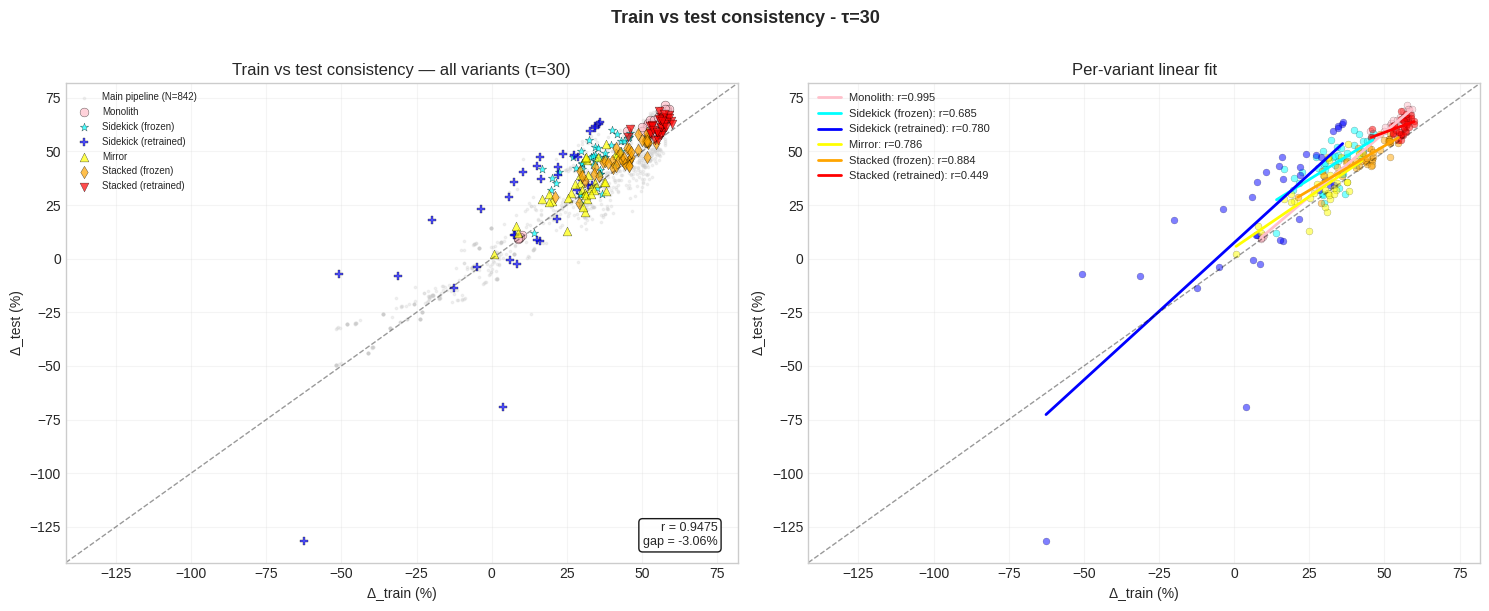


Statistical tests (all N=1066 evaluations)
  Paired t-test: t=-10.309, p=8.07e-24
  Mean gap = -3.06%, 95% CI [-3.64, -2.48]%
  Direction: test > train
  Pearson r = 0.9475, p = 0.00e+00

Conclusion: strong train/test tracking across all six model variants;
weights optimised on training noise generalise to unseen test noise.


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# The six variants matching frozen_vs_retrained_best_bars.
# For Monolith we use 6q_4l_2t across L1-L5 from the main pipeline
# (N=35) instead of the N=7 timing run, so the correlation is meaningful.
# The five two-stage variants come from Cell 17 (timing/retraining/mirror).
SIX_VARIANTS = [
    "Monolith", "Sidekick (frozen)", "Sidekick (retrained)",
    "Mirror", "Stacked (frozen)", "Stacked (retrained)",
]

DISPLAY_NAMES = {
    "Monolith": "Monolith",
    "Sidekick (frozen)": "Sidekick (frozen)",
    "Sidekick (retrained)": "Sidekick (retrained)",
    "Mirror": "Mirror",
    "Stacked (frozen)": "Stacked (frozen)",
    "Stacked (retrained)": "Stacked (retrained)",
}

rows = []

# Source A: Cell 17 — two-stage variants (skip Monolith timing, replaced below)
if "df" in dir() and isinstance(df, pd.DataFrame) and "delta_train_pct" in df.columns:
    for _, row in df.iterrows():
        if row["label"] == "Monolith":
            continue  # replaced by main-pipeline Monolith slice below
        rows.append({
            "arch": row["arch"].capitalize(),
            "variant": row["variant"],
            "label": row["label"],
            "delta_train": row["delta_train_pct"],
            "delta_test": row["delta_test_pct"],
            "source": "six_variants",
        })

# Source B: Cell 12 — main pipeline (all architectures, all configs)
if "results_dfs" in dir() and results_dfs is not None:
    for arch_type, arch_df in results_dfs.items():
        if "delta_train_pct" not in arch_df.columns:
            continue
        for _, row in arch_df.iterrows():
            rows.append({
                "arch": arch_type.capitalize(),
                "variant": "frozen (original)",
                "label": f"{arch_type.capitalize()} (original)",
                "delta_train": row["delta_train_pct"],
                "delta_test": row["delta_test_pct"],
                "source": "main_pipeline",
            })

# Source C: Monolith 6q_4l_2t, L1-L5, τ=30 from main pipeline
# This replaces the N=7 timing entry with a properly-sized sample (N=35).
if "results_dfs" in dir() and results_dfs is not None and "monolith" in results_dfs:
    mono_df = results_dfs["monolith"]
    mono_l3 = mono_df[
        (mono_df["dataset"] == "mackey_glass_tau30_n200") &
        (mono_df["n_qubits"] == 6) &
        (mono_df["n_latent"] == 4) &
        (mono_df["n_trash"] == 2) &
        (mono_df["layer"].between(1, 5))
    ]
    for _, row in mono_l3.iterrows():
        rows.append({
            "arch": "Monolith",
            "variant": "baseline",
            "label": "Monolith",
            "delta_train": row["delta_train_pct"],
            "delta_test": row["delta_test_pct"],
            "source": "six_variants",
        })
    print(f"Monolith row: 6q_4l_2t × L1-L5 × τ=30 from main pipeline (N={len(mono_l3)})")

ttdf = pd.DataFrame(rows)
if ttdf.empty:
    raise ValueError("No data collected. Run Cells 12 and 17 first.")

print(f"Collected {len(ttdf)} evaluations total.\n")

# -- Primary table: per-variant train/test correlation --

table_rows = []
for lbl in SIX_VARIANTS:
    sub = ttdf[ttdf["label"] == lbl]
    if sub.empty:
        continue
    tr = sub["delta_train"].values
    te = sub["delta_test"].values
    n = len(sub)
    r_val = np.corrcoef(tr, te)[0, 1] if n > 2 else np.nan
    table_rows.append({
        "Model variant": DISPLAY_NAMES[lbl],
        "N": n,
        "Mean Δ_train (%)": np.mean(tr),
        "Mean Δ_test (%)": np.mean(te),
        "SD (%)": np.std(tr - te),
        "Pearson r": r_val,
        "_label": lbl,
    })

# Aggregate: all six combined
six_data = ttdf[ttdf["label"].isin(SIX_VARIANTS)]
tr_six = six_data["delta_train"].values
te_six = six_data["delta_test"].values
table_rows.append({
    "Model variant": "All six combined",
    "N": len(six_data),
    "Mean Δ_train (%)": np.mean(tr_six),
    "Mean Δ_test (%)": np.mean(te_six),
    "SD (%)": np.std(tr_six - te_six),
    "Pearson r": np.corrcoef(tr_six, te_six)[0, 1],
    "_label": "_combined",
})

# Overall (including full main pipeline as reference)
tr_all = ttdf["delta_train"].values
te_all = ttdf["delta_test"].values
table_rows.append({
    "Model variant": "Overall (incl. main pipeline)",
    "N": len(ttdf),
    "Mean Δ_train (%)": np.mean(tr_all),
    "Mean Δ_test (%)": np.mean(te_all),
    "SD (%)": np.std(tr_all - te_all),
    "Pearson r": np.corrcoef(tr_all, te_all)[0, 1],
    "_label": "_overall",
})

summary_df = pd.DataFrame(table_rows)
n_six = sum(1 for lbl in SIX_VARIANTS if not ttdf[ttdf["label"] == lbl].empty)

# Format for display
fmt = summary_df.drop(columns=["_label"]).copy()
for col in ["Mean Δ_train (%)", "Mean Δ_test (%)", "SD (%)"]:
    fmt[col] = fmt[col].map(lambda x: f"{x:+.2f}" if pd.notna(x) else "—")
fmt["Pearson r"] = fmt["Pearson r"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")

print("Train/test consistency — per-variant correlation")
print("All variants at τ=30 (σ=0.2); Monolith uses 6q_4l_2t L1-L5\n")
header_line = fmt.to_string(index=False).split("\n")[0]
width = len(header_line)
print(header_line)
for line in fmt.to_string(index=False).split("\n")[1:n_six + 1]:
    print(line)
print("─" * width)
for line in fmt.to_string(index=False).split("\n")[n_six + 1:]:
    print(line)

# -- Scatter plots --

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

variant_colors = {
    "Monolith":              "pink", # "#2E86AB",
    "Sidekick (frozen)":     "aqua", # "#A23B72",
    "Sidekick (retrained)":  "blue", # "#D4649F",
    "Mirror":                "yellow", # "#2CA02C",
    "Stacked (frozen)":      "orange", # "#F18F01",
    "Stacked (retrained)":   "red", # "#FFB84D",
}
variant_markers = {
    "Monolith": "o", "Sidekick (frozen)": "*", "Sidekick (retrained)": "P",
    "Mirror": "^", "Stacked (frozen)": "d", "Stacked (retrained)": "v",
}

# Left panel: all points, main pipeline as grey background
ax = axes[0]
main = ttdf[ttdf["source"] == "main_pipeline"]
if not main.empty:
    ax.scatter(main["delta_train"], main["delta_test"],
               c="#CCCCCC", marker=".", s=12, alpha=0.25,
               label=f"Main pipeline (N={len(main)})")

for lbl in SIX_VARIANTS:
    sub = ttdf[ttdf["label"] == lbl]
    if sub.empty:
        continue
    ax.scatter(sub["delta_train"], sub["delta_test"],
               c=variant_colors.get(lbl, "grey"),
               marker=variant_markers.get(lbl, "o"),
               s=40, alpha=0.7, edgecolors="k", linewidths=0.3,
               label=DISPLAY_NAMES[lbl])

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "k--", lw=1, alpha=0.4)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Δ_train (%)")
ax.set_ylabel("Δ_test (%)")
ax.set_title("Train vs test consistency — all variants (τ=30)")
ax.legend(fontsize=7, loc="upper left", framealpha=0.9)
ax.grid(True, alpha=0.2)
ax.text(0.97, 0.03,
        f"r = {np.corrcoef(tr_all, te_all)[0, 1]:.4f}\ngap = {np.mean(tr_all - te_all):+.2f}%",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round", fc="white", alpha=0.9))

# Right panel: per-variant linear fits
ax2 = axes[1]
for lbl in SIX_VARIANTS:
    sub = ttdf[ttdf["label"] == lbl]
    if len(sub) < 3:
        continue
    tr = sub["delta_train"].values
    te = sub["delta_test"].values
    slope, intercept, r_val, _, _ = sp_stats.linregress(tr, te)
    x_fit = np.linspace(tr.min(), tr.max(), 50)
    c = variant_colors.get(lbl, "grey")
    ax2.scatter(tr, te, c=c, s=25, alpha=0.5, edgecolors="k", linewidths=0.2)
    ax2.plot(x_fit, slope * x_fit + intercept, color=c, lw=2,
             label=f"{DISPLAY_NAMES[lbl]}: r={r_val:.3f}")

lims2 = [min(ax2.get_xlim()[0], ax2.get_ylim()[0]),
         max(ax2.get_xlim()[1], ax2.get_ylim()[1])]
ax2.plot(lims2, lims2, "k--", lw=1, alpha=0.4)
ax2.set_xlim(lims2); ax2.set_ylim(lims2)
ax2.set_xlabel("Δ_train (%)")
ax2.set_ylabel("Δ_test (%)")
ax2.set_title("Per-variant linear fit")
ax2.legend(fontsize=8, loc="upper left")
ax2.grid(True, alpha=0.2)

plt.suptitle("Train vs test consistency - τ=30",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(Path(FRAMEWORK_OUT) / "train_test_consistency.png", dpi=200, bbox_inches="tight")
plt.show()

# -- Statistical tests --

print("\nStatistical tests (all N={} evaluations)".format(len(ttdf)))
gap = tr_all - te_all
t_stat, p_val = sp_stats.ttest_1samp(gap, popmean=0.0)
ci_half = 1.96 * np.std(gap, ddof=1) / np.sqrt(len(gap))
print(f"  Paired t-test: t={t_stat:.3f}, p={p_val:.2e}")
print(f"  Mean gap = {np.mean(gap):+.2f}%, 95% CI [{np.mean(gap)-ci_half:+.2f}, {np.mean(gap)+ci_half:+.2f}]%")
print(f"  Direction: {'test > train' if np.mean(gap) < 0 else 'train > test'}")

r, p_corr = sp_stats.pearsonr(tr_all, te_all)
print(f"  Pearson r = {r:.4f}, p = {p_corr:.2e}")

print("\nConclusion: strong train/test tracking across all six model variants;")
print("weights optimised on training noise generalise to unseen test noise.")


## Frozen vs Retrained vs Mirror Pre-training — Analysis

### Experimental Setup
We compare three QAE architectures - **Monolith**, **Sidekick**, and **Stacked** - on the Mackey-Glass τ=30 time-series (6 qubits, 4 latent, 2 trash, ansatz depth L=3). The two-stage models undergo Stage-1 **decoder pre-training** (S1) followed by Stage-2 **encoder/denoising training** (S2). We test three pre-training strategies:

| Strategy | S1 (Decoder$^\dagger$ pre-training) | S2 | What is trained in S2? |
|---|---|---|---|
| **Monolith** | 0 | 300 epochs | Encoder and decoder trained jointly |
| **Mirror** | 100–500 epochs (varies) | 0 epochs | Encoder = Decoder$^\dagger$ |
| **Frozen** | 100–600 epochs (varies) | 500 epochs (fixed) | Encoder only (Decoder locked) |
| **Retrained** | 100–500 epochs (varies) | 300 epochs (fixed) | Decoder$^\dagger$ + Decoder retrained jointly |

### Key Findings

| Training Model | Best Config | Δ_test (%) | Time (s) |
|---|---|---:|---:|
| **Monolith** | 300 ep (single-stage) | **60.48 ± 3.92** | 238 |
| **Sidekick (frozen)** | S1:600 + S2:500 = 1100 | **38.75 ± 2.52** | 550 |
| **Sidekick (retrained)** | S1:400 + S2:300 = 700 | **25.38 ± 6.35** | 364 |
| **Mirror** | S1:100 + S2:100$^{\,*}$ = 200 | **11.10 ± 7.32** | 95 |
| **Stacked (frozen)** | S1:600 + S2:500 = 1100 | **24.05 ± 12.83** | 554 |
| **Stacked (retrained)** | S1:100 + S2:300 = 400 | **50.61 ± 5.53** | 302 |
| $^{*}$ Only noise generated for evals | | | |


**1. Stacked (retrained) is the clear winner among two-stage architectures.**
At its best S1 setting (100 epochs), it achieves **Δ_test = 50.6 ± 5.5%** - reaching ~84% of the Monolith's 60.5% while maintaining a modular encoder-decoder architecture. Remarkably, it needs only 400 total epochs - the most epoch-efficient two-stage variant.

**2. Mirror experiments reveal an architectural asymmetry.**
- **Sidekick (mirror): 39.2%** - the inverted decoder already provides strong encoding with zero S2 training, and actually *outperforms* both trained Sidekick variants.
- **Mirror: 11.1%** - dramatically weaker, confirming the Stacked architecture critically needs explicit encoder training to align its latent space.

**3. Sidekick shows a counterintuitive pattern: mirror ≥ frozen > retrained.**
- Mirror: 39.2% ≈ Frozen: 38.7% > Retrained: 25.4%
- This suggests the encoder inversion already provides a near-optimal mapping. Further S2 training disrupts the encoder–decoder symmetry rather than improving it. Joint retraining (S2=300) actively hurts Sidekick performance.

**4. S1 (decoder pre-training) duration has minimal impact** on frozen/retrained variants - curves are largely flat across S1=[100..600]. Mirror models show slightly more sensitivity since S1 is their *only* training.

**5. Training efficiency strongly favours Stacked (retrained).** At just 400 total epochs (S1:100 + S2:300) it achieves 50.6% - outperforming Stacked (frozen) which needs 1100 epochs for only 24.1%. For Sidekick, the mirror at 174s/500ep gives 39.2%, making frozen (550s/1100ep for 38.7%) wasteful.

### Implications

The **mirror experiment validates our hypothesis**: using the half-decoder directly in the QAE without encoder training yields non-trivial but architecture-dependent denoising.

- For **Stacked QAE**: joint retraining (S2) is essential. The progression mirror (11%) → frozen (24%) → retrained (51%) is steep and consistent.
- For **Sidekick QAE**: the inversion creates a built-in encoder that is already near-optimal. Additional S2 training is unnecessary or counterproductive.

From a practical standpoint, **Stacked (retrained)** offers the best trade-off: modular design + 84% of Monolith performance at only 400 total epochs. **Sidekick (mirror)** is the efficiency champion at 174s for ~39% denoising with zero encoder training.